In [2]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [3]:
@load "combined_dfs.jld2" combined_dfs
@load "metrics_combined.jld2" metrics_combined
@load "dc_delta.jld2" dc_delta

1-element Vector{Symbol}:
 :dc_delta

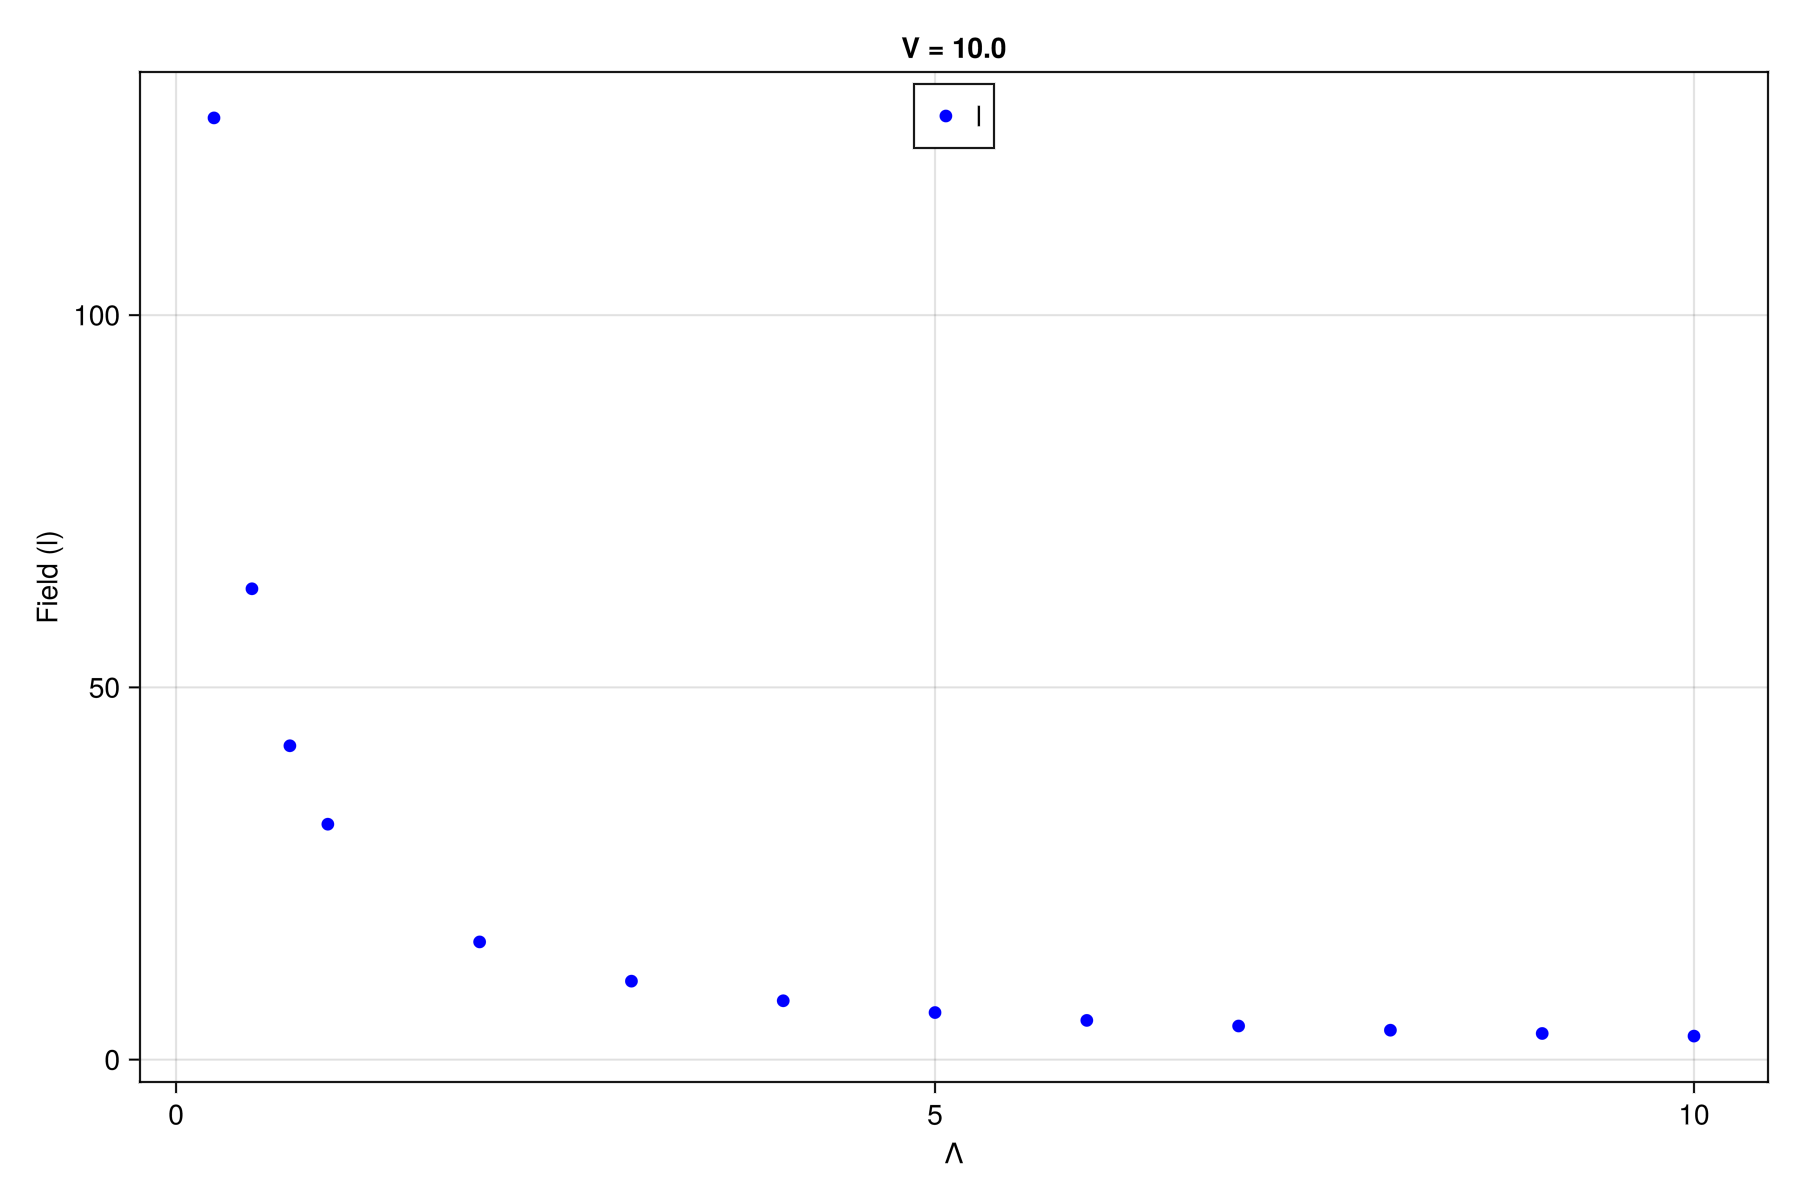

In [4]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "V = 10.0", xlabel = "Λ", ylabel = "Field (l)", yaxisposition = :left)
# ax1 = Axis(fig[1,1], title = "V = 10.0", xlabel = "Λ", ylabel = "delta", yaxisposition = :right)

mask = (dc_delta.v .== 10.0)
Dc = dc_delta.Dc[mask]
delta = dc_delta.delta[mask]
lambda = dc_delta.lambda[mask]
l = sqrt.(Dc./delta)

scatter!(ax, lambda, l, color = :blue, label = "l")
# scatter!(ax1, lambda, delta, color = :violet, label = "delta")

axislegend(ax, position = :ct)
# axislegend(ax1, position = :rc)
fig

In [5]:
save("Plots/Fixed_source_model/Lambda_l_v10.png", fig)

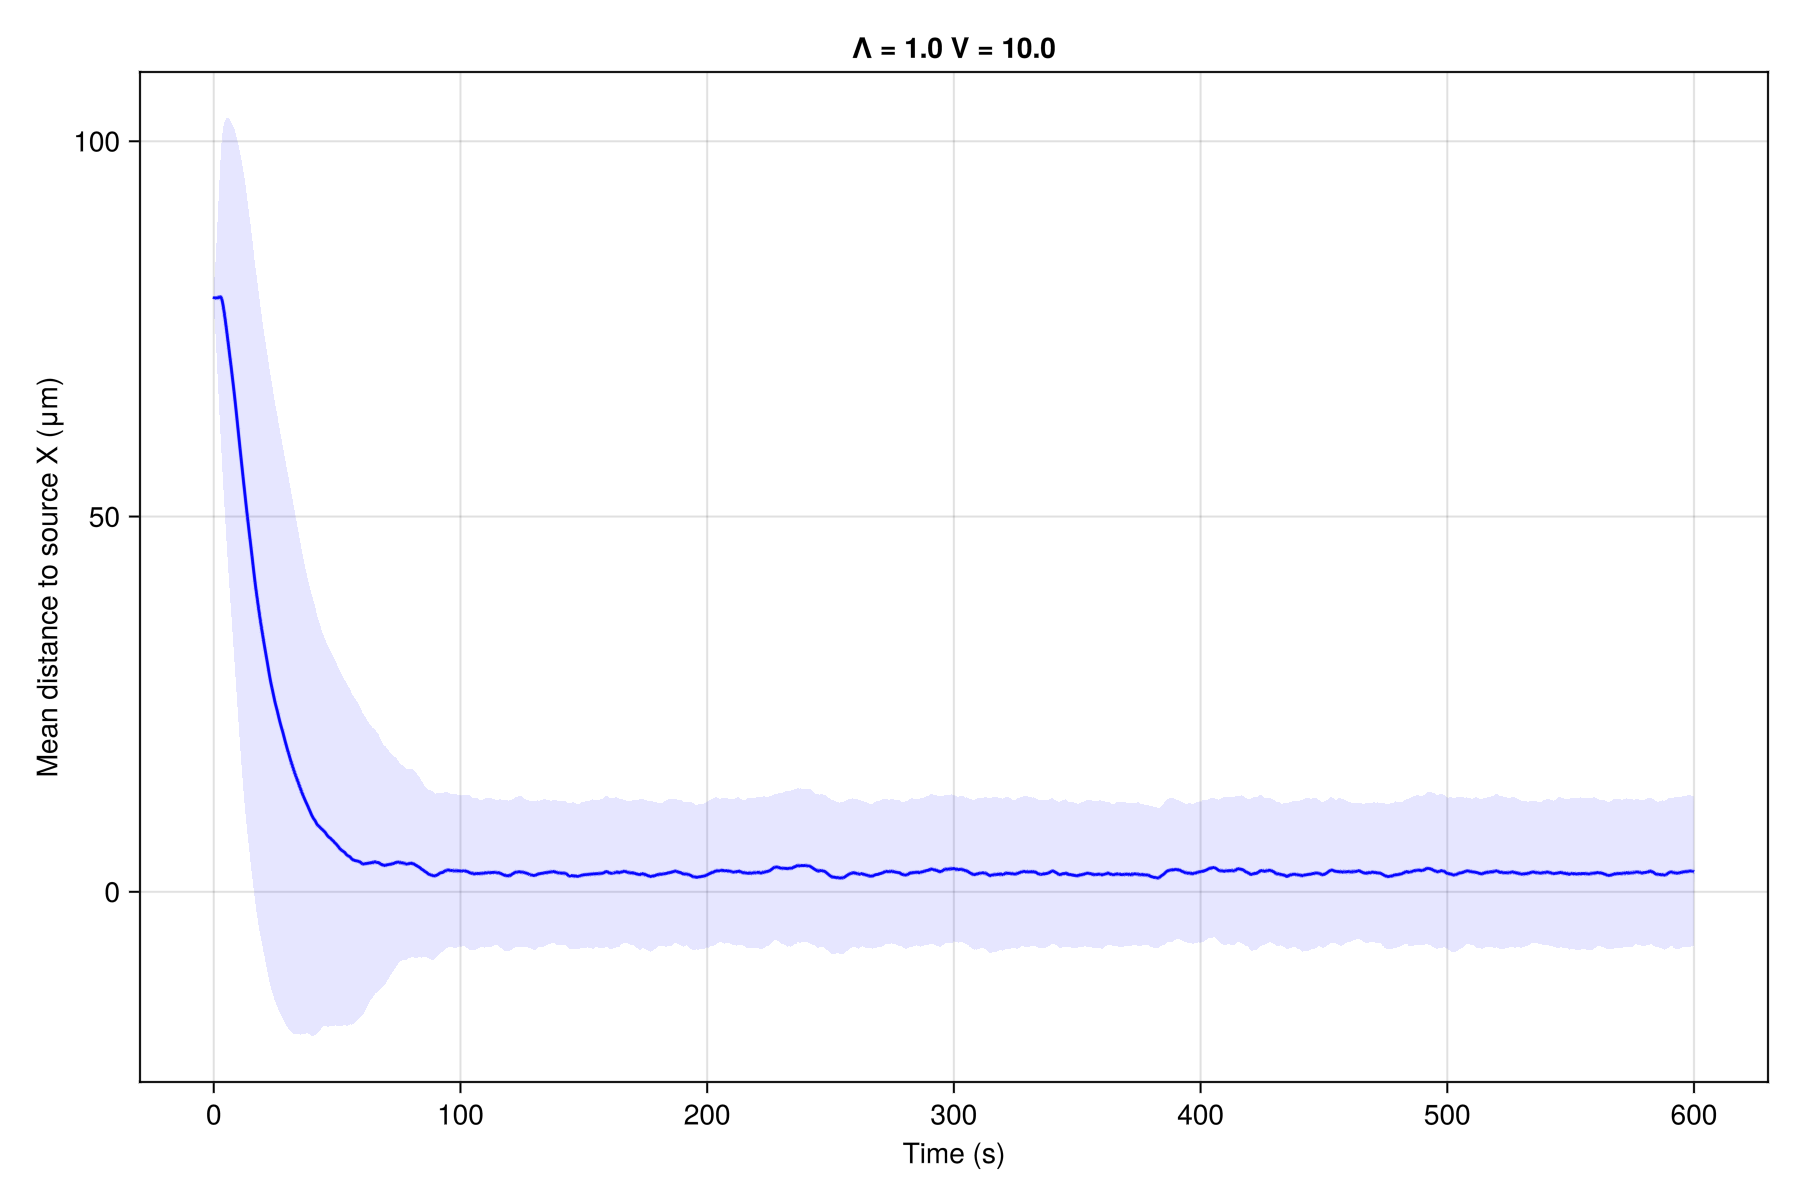

In [7]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Λ = 1.0 V = 10.0", xlabel = "Time (s)", ylabel = "Mean distance to source X (μm)")
df = combined_dfs[(10.0, 1.0)]
grouped = groupby(df, :step)
mean_x = Float64[]
std_x = Float64[]
for i in 1:length(grouped)
    data = grouped[i]
    x = mean(data.x)
    push!(mean_x, x)
    push!(std_x, std(data.x))
end
time = (1:6000)*0.1
lines!(ax, time, mean_x, color = :blue)
band!(ax, time, mean_x .- std_x, mean_x .+ std_x, color = (:blue, 0.1))

fig

In [8]:
save("Plots/Fixed_source_model/Presentation_meandist.png", fig)

In [3]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

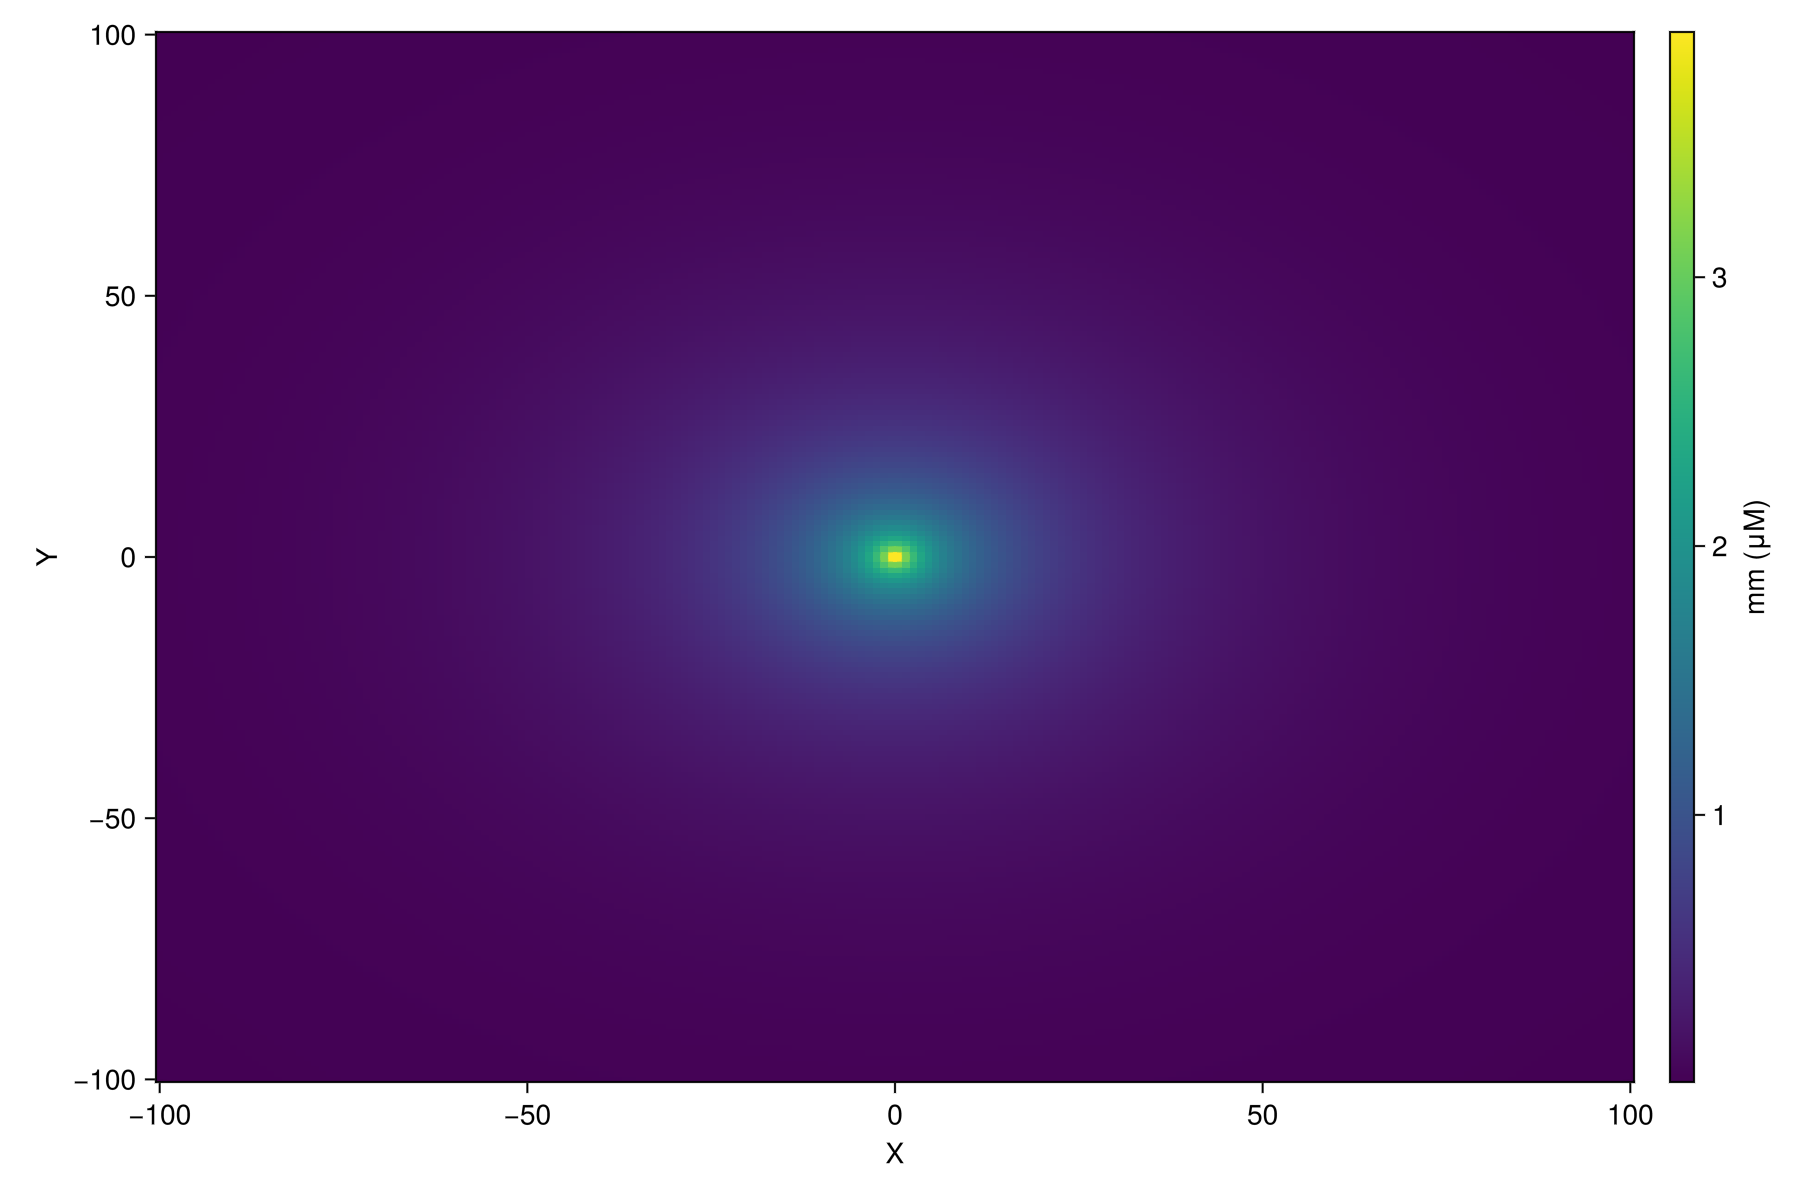

GLMakie.Screen(...)

In [ ]:
fig2 = Figure(size=(900,600))

model_steps = 1:60000

xs, ys = 0.0, 0.0


len = Int(100 + 100)

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(10 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)
ax = Axis(fig2[1,1], xlabel = "X", ylabel = "Y")

hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)

Colorbar(fig2[1, 2], hm, label="mm (μM)")

display(fig2)

In [6]:
save("Plots/Fixed_source_model/bessel_field_hm.png", fig2)

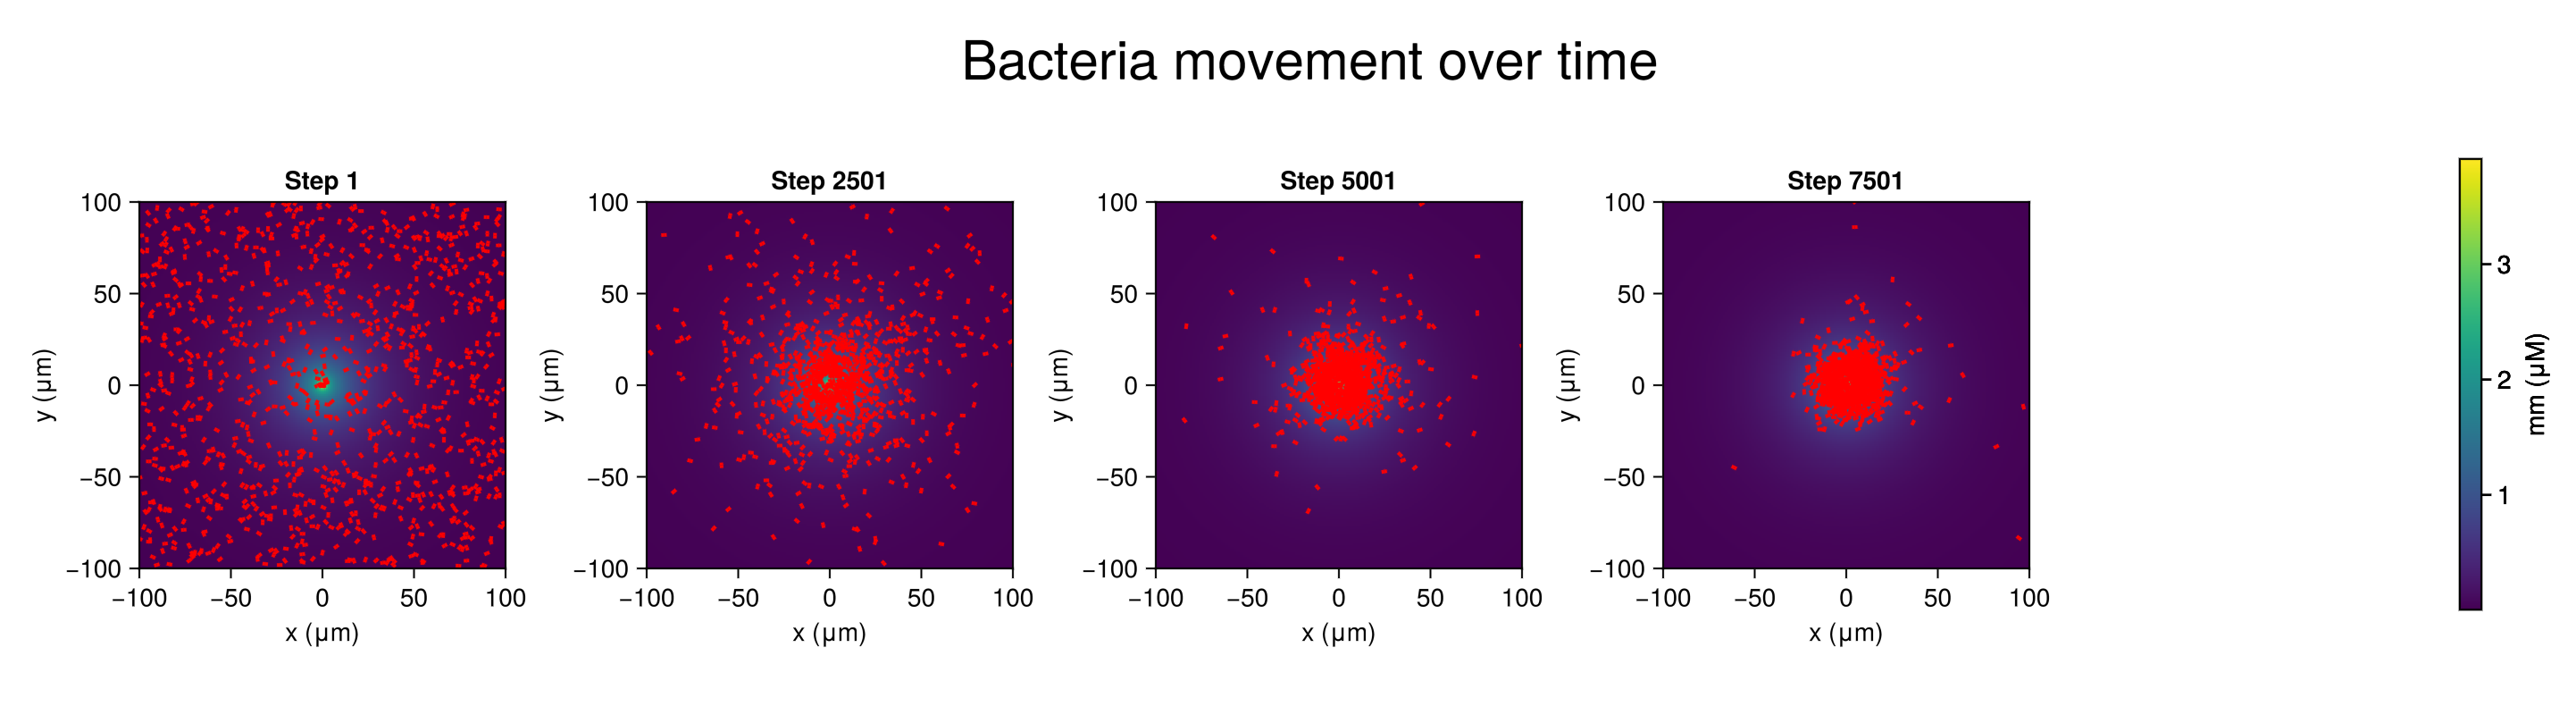

GLMakie.Screen(...)

In [11]:
fig2 = Figure(size=(2100,400))

model_steps = 1:10000
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

xs, ys = 0.0, 0.0


len = Int(100 + 100)
# x_grid = range(com.simBox[1], com.simBox[3], length=len)
# y_grid = range(com.simBox[2], com.simBox[4], length=len)
x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(10 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

jldopen("fsb_example.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig2[1, 1*j-1], aspect=1, title="Step $step",  xlabel="x (μm)", ylabel="y (μm)")
        xlims!(ax, -100, 100)
        ylims!(ax, -100, 100)

        g = file[@sprintf("step_%06d", step)]

        hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)
        Colorbar(fig2[1, 5], hm, label="mm (μM)")


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
                
        # scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")

            
            # Compute rod endpoints
            xs1 = x .+ l ./ 2 .* cos.(theta)
            ys1 = y .+ l ./ 2 .* sin.(theta)
            xs2 = x .- l ./ 2 .* cos.(theta)
            ys2 = y .- l ./ 2 .* sin.(theta)

            for i in 1:length(x)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end

    end
end
# sideinfo = Label(fig2[2, 1:5], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
supertitle  = Label(fig2[0, :], "Bacteria movement over time", fontsize = 30)

display(fig2)

In [12]:
save("Plots/Fixed_source_model/Exemple_movement_2.png", fig2)

2000.0


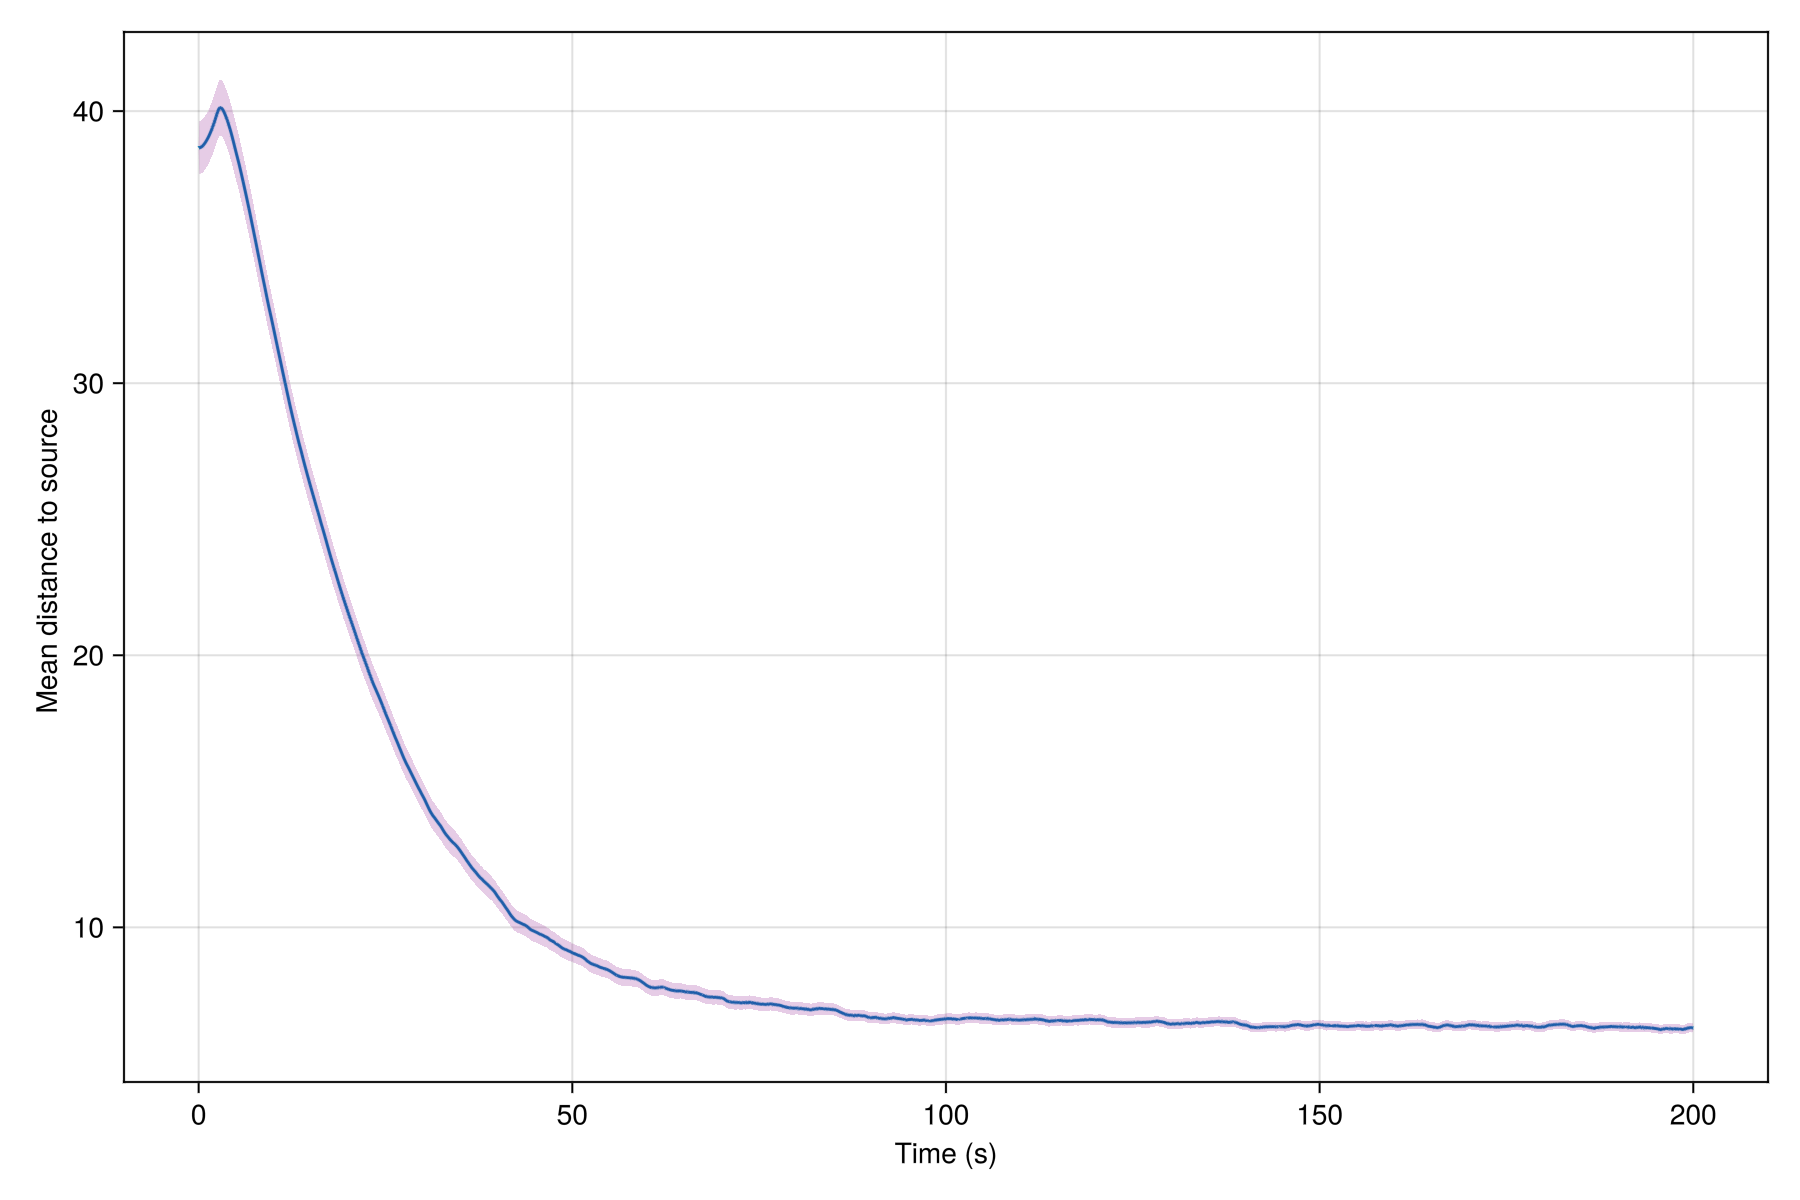

GLMakie.Screen(...)

In [25]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source ")
# ax2 = Axis(fig3[1,2], xlabel="Time (s)", ylabel="Mean distance to source (Y)")
steps = 20000
mean_dist_x = Float64[] 
std_dist_x = Float64[]
mean_dist_y = Float64[] 
std_dist_y = Float64[]
mean_dist = Float64[]
std_dist = Float64[]
agents = Float64[]

jldopen("fsb_example.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = 0
        ys = 0

        other_x = g["x"]

        other_y = g["y"]

        dists_x = other_x .- xs
        dists_y = other_y .- ys
        dists = sqrt.((other_x .-  xs).^2 .+ (other_y .- ys).^2)

        # push!(mean_dist_x, mean(dists_x))
        push!(mean_dist, mean(dists))
        push!(agents, length(dists))
        # push!(std_dist_x, std(dists_x))
        push!(std_dist, std(dists))
        # push!(mean_dist_y, mean(dists_y))
        # push!(std_dist_y, std(dists_y))

    end
    println(agents[1])

    std_X = std_dist_x ./ sqrt(agents[1])
    std_Y = std_dist_y ./ sqrt(agents[1])
    std_D = std_dist ./ sqrt(agents[1])

    lines!(ax1, (1:steps)*0.01, mean_dist)
    # band!(ax1, (1:steps)*0.01, mean_dist_x .- std_X, mean_dist_x .+ std_X, color=(:purple, 0.2), label = "Standard deviation")
    
    # lines!(ax2, (1:steps)*0.01, mean_dist_y)
    # band!(ax2, (1:steps)*0.01, mean_dist_y .- std_Y, mean_dist_y .+ std_Y, color=(:purple, 0.2), label = "Standard deviation") 
    # #Standard deviation

    # lines!(ax1, log.((1:steps)*0.01), log.(mean_dist))
    band!(ax1, (1:steps)*0.01, mean_dist .- std_D, mean_dist .+ std_D, color=(:purple, 0.2), label = "Standard deviation")  #Standard deviation
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist, mean_dist .+ std_dist, color=(:yellow, 0.2), label = "Standard error")      #Standard error

    # errorbars!(ax1, (1:steps)*0.01, mean_dist, std_dist, label = "Std deviation", color = (:red, 0.2), whiskerwidth = 0.1)
end
# sideinfo = Label(fig3[2, 1], "Model parameters = DMedium: $(com.DMedium), v: [$(com.v[1])μm/s], tm: [$(com.τm[1])s]", justification = :left, color = :grey)
# supertitle  = Label(fig3[0, :], "Distance to source", fontsize = 30)
# axislegend(ax1, position =:rt)
display(fig3)

In [26]:
save("Plots/Fixed_source_model/example_mean_dist.png", fig3)

In [10]:
data = Dict{Int, Any}()
steps = 20000
jldopen("fsb_10.0_lambda_1.0.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"])
            # "l" => copy(key["l"]),
            # "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
# source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

xs, ys = 0.0, 0.0


len = Int(100 + 100)
# x_grid = range(com.simBox[1], com.simBox[3], length=len)
# y_grid = range(com.simBox[2], com.simBox[4], length=len)
x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

X, Y = meshgrid(x_grid, y_grid)

λ = sqrt(10 / 0.01)
# λ = sqrt(com.DMedium / com.delta)

r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

mm_grid = @. 1.0 * besselk(0, r / λ)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    # mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (200,200))

    hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)
    # Colorbar(fig2[1, 2], hm, label="mm (μM)")

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = 3

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    autolimits!(ax)
end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)

In [7]:
field_merge = innerjoin(metrics_combined, dc_delta, on = [:v, :lambda])

Row,v,lambda,mu_x,mu_y,sigma_x,sigma_y,k_x,k_y,Dc,delta
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,5.0,0.25,2.59492,2.67258,8.09596,7.89805,0.00137991,0.00138897,40.0,0.01
2,5.0,0.5,2.36836,2.42104,6.5484,6.50722,0.00252474,0.00246432,20.0,0.02
3,5.0,0.75,2.54192,2.5562,6.05206,6.1209,0.00320385,0.00321971,13.33,0.03
4,5.0,1.0,2.89775,2.8263,5.9946,5.96359,0.00349954,0.00365125,10.0,0.04
5,5.0,2.0,4.35303,4.25107,6.3092,6.34025,0.00388497,0.00382129,5.0,0.08
6,5.0,3.0,5.09385,5.03858,6.39762,6.44408,0.00364838,0.00366495,3.33333,0.12
7,5.0,4.0,5.09672,5.08283,6.22925,6.19946,0.00344543,0.00382214,2.5,0.16
8,5.0,5.0,4.86336,4.82832,7.05832,6.82974,0.00404968,0.00352136,2.0,0.2
9,5.0,6.0,4.67125,4.67106,8.08399,7.55588,0.00340852,0.00426279,1.66667,0.24


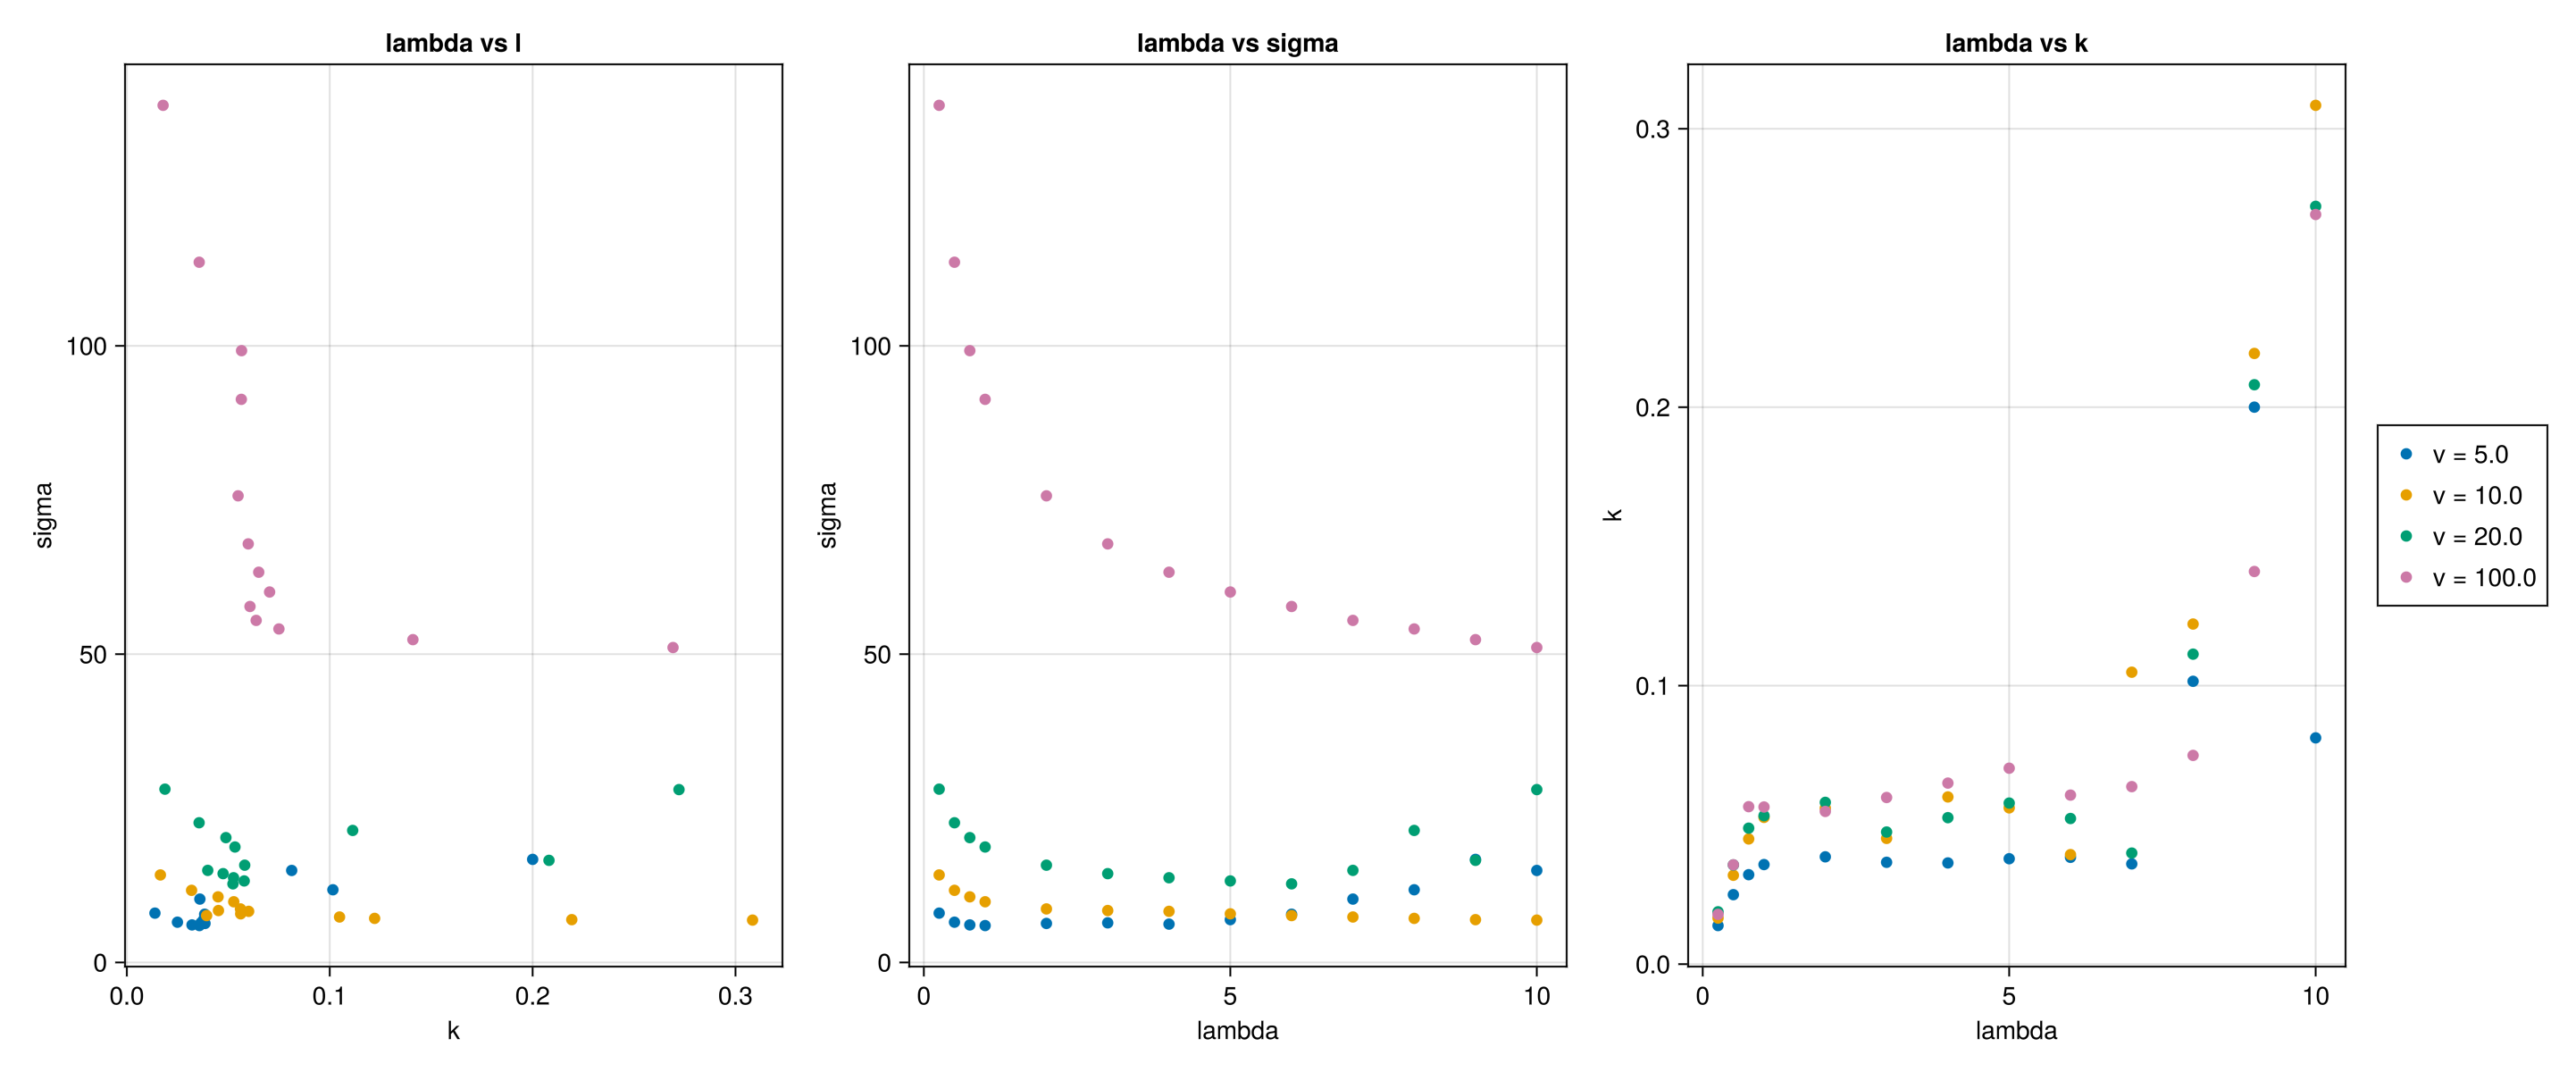

In [9]:
lambda = field_merge.lambda
sigma = (field_merge.sigma_x .+ field_merge.sigma_y) ./ 2
k     = ((field_merge.k_x .+ field_merge.k_y) ./ 2)*10
vvals = field_merge.v

Dc = field_merge.Dc
delta = field_merge.delta
l = sqrt.(Dc ./ delta)

D = sigma .* sqrt.(2 .* k)

fig = Figure(size = (2100, 600))

ax1 = Axis(fig[1, 1],
    xlabel = "k",
    ylabel = "sigma",
    title = "lambda vs l"
)

ax2 = Axis(fig[1, 2],
    xlabel = "lambda",
    ylabel = "sigma",
    title = "lambda vs sigma"
)

ax3 = Axis(fig[1, 3],
    xlabel = "lambda",
    ylabel = "k",
    title = "lambda vs k"
)

# ax4 = Axis(fig[2,1],
#     xlabel = "k",
#     ylabel = "field (l)",
#     title = "k vs l"
# )

# ax5 = Axis(fig[2,2],
#     xlabel = "k",
#     ylabel = "sigma",
#     title = "k vs sigma"
# )

# ax6 = Axis(fig[2,3],
#     xlabel = "k",
#     ylabel = "Dc",
#     title = "k vs Dc"
# )

# ax7 = Axis(fig[3,1],
#     xlabel = "sigma",
#     ylabel = "field(l)",
#     title = "sigma vs l"
# )

# ax8 = Axis(fig[3,2],
#     xlabel = "sigma",
#     ylabel = "delta",
#     title = "sigma vs delta"
# )

# ax9 = Axis(fig[3,3],
#     xlabel = "sigma",
#     ylabel = "Dc",
#     title = "sigma vs Dc"
# )
# unique velocities
unique_v = [5.0, 10.0, 20.0, 100.0]

# choose a color palette
colors = Makie.wong_colors()

for (i, v) in enumerate(unique_v)

    idx = findall(==(v), vvals)

    c = colors[i]

    scatter!(ax1, k[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax2, lambda[idx], sigma[idx],
        color = c,
        label = "v = $v"
    )

    scatter!(ax3, lambda[idx], k[idx],
        color = c,
        label = "v = $v"
    )

    # scatter!(ax4, k[idx], l[idx],
    #     color = c,
    #     label = "v = $v"
    # )  

    # scatter!(ax5, k[idx], sigma[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 

    # scatter!(ax6, k[idx], Dc[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 

    # scatter!(ax7, sigma[idx], l[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 

    # scatter!(ax8, sigma[idx], delta[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 

    # scatter!(ax9, sigma[idx], Dc[idx],
    #     color = c,
    #     label = "v = $v"
    # ) 
end

leg = Legend(fig[1,4], ax1)

fig

In [10]:
save("Plots/Fixed_source_model/presentacio_parameters_bona.png", fig)

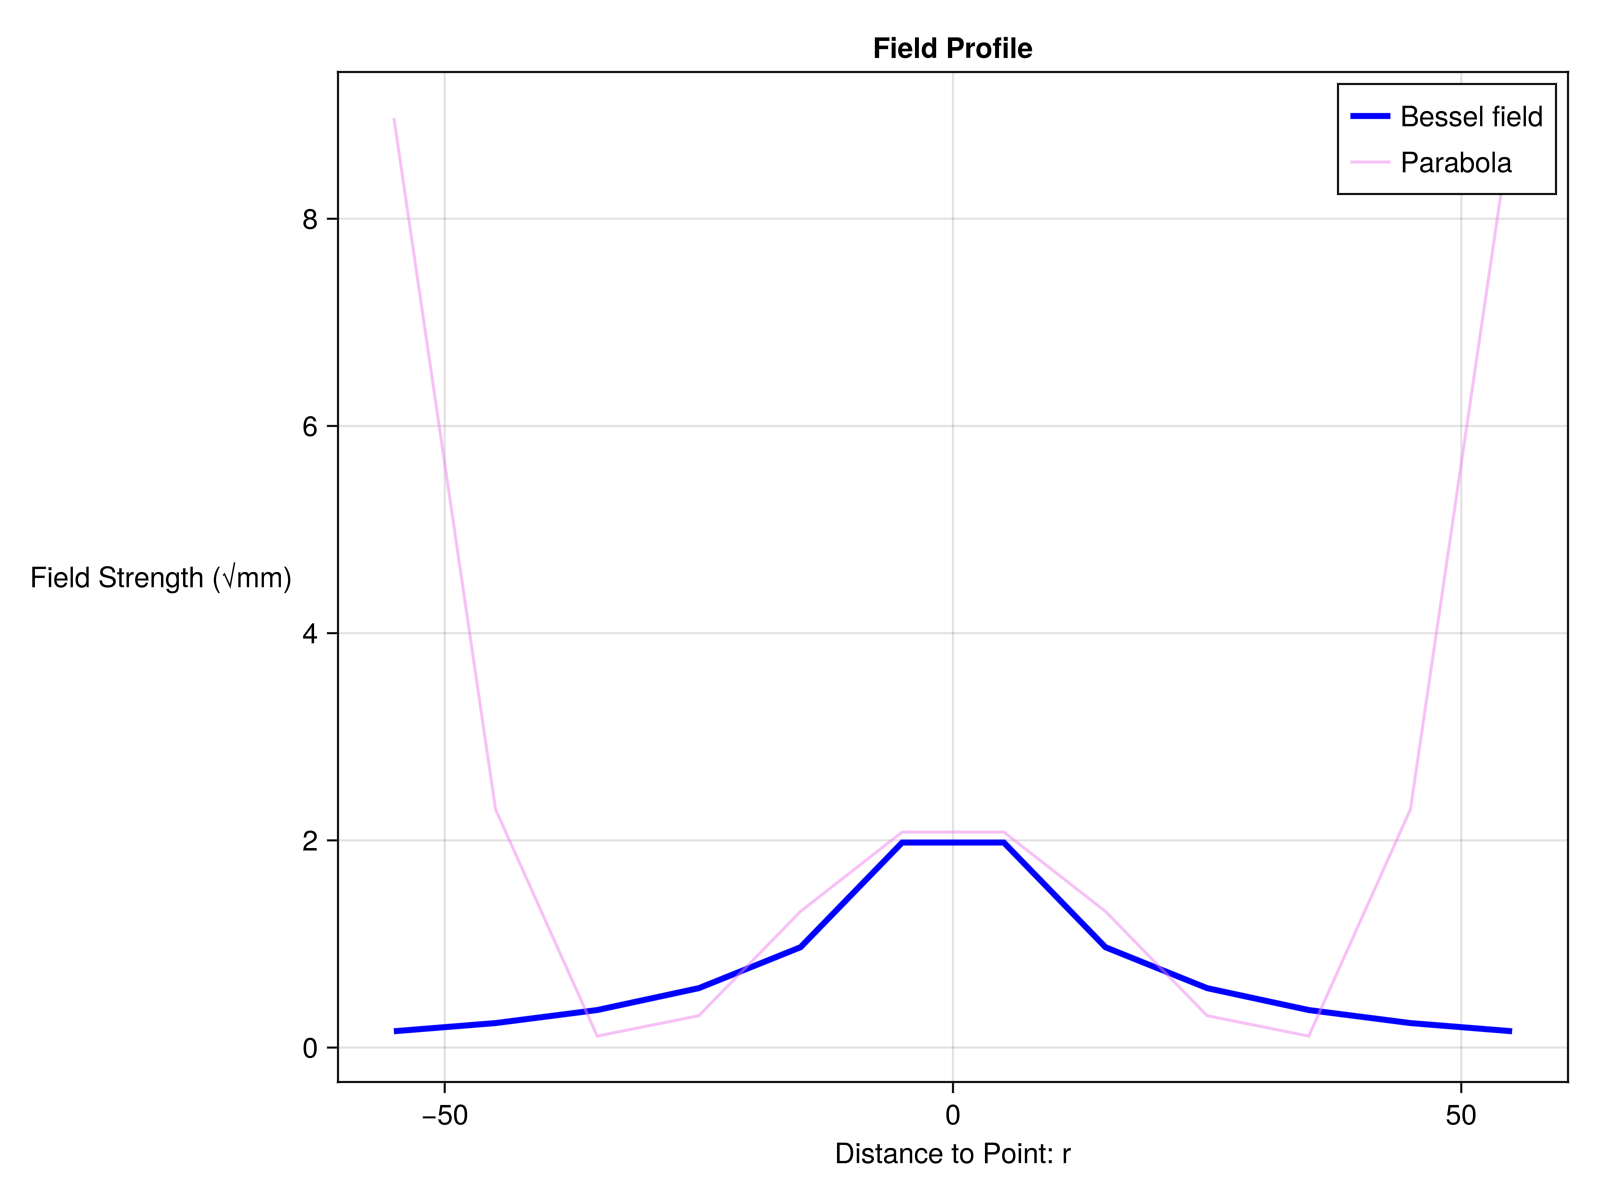

In [48]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 55        # Maximum distance to plot (e.g., 5 * ll)

# Generate distance vector (x-axis)
# Start at 0.01 to avoid the singularity at r=0 (K0(0) -> Inf)
# r = LinRange(-55, r_max, 10) 
x = -55:10:55
# x = -100:10:100

# --- 2. CALCULATION ---
# Calculate m = 1.0 * K0(r / ll)
# besselk(0, x) is the modified Bessel function of the second kind, order 0
m_vals = mm_factor .* besselk.(0, abs.(x) ./ ll)

# Calculate the square root
# Ensure we don't take sqrt of negative numbers (K0 is positive for r>0)
sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: r",
          ylabel = "Field Strength (√mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, x, m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "Bessel field")
# h = 1.0          # Peak concentration
# b = ll      # Width of the parabola

# y = h .* (1 .- (x.^2 ./b^2.1))
# y = h .* (1 .-(x.^2 ./ll .^2*2))

b = 26
c = ll
y = ((x .^2 .- c .^2) ./b .^2) .^2
# h = 0.001
# c = ll
# b = 0.6

y1 = h .* (1 .+ ((x .- c).^2)/b .^2)
y2 = h .* (1 .+ ((x .+ c).^2)/b .^2)



# lines!(ax, x, y)

# a=2*ll
# y1= ((x).-a).^2 
# y2= ((x).+a).^2 
lines!(ax, x, y, label = "Parabola", color = (:violet, 0.5))
# lines!(ax, x, y1, label = "Parabola 1", color = (:violet, 0.5))
# lines!(ax, x, y2, label = "Parabola 2", color = (:pink, 0.5))


# slope_x, intercept_x = linear_fit(x, sqrt_m_vals)
# fitted_line_x = [intercept_x + slope_x * t for t in r]
# lines!(ax, x, fitted_line_x, label = "$(round(slope_x, digits = 4))", color = :red, linestyle = :dash)
# ylims!(ax, 0, 7)
# xlims!(ax, -100, 100)


# Add legend
axislegend(ax, position = :rt)

# Display the figure
fig

In [49]:
save("Plots/Fixed_source_model/presentation_approximation_parabole_wells.png", fig)

# v = 10 trajectories


In [5]:
velocities = [5.0, 10.0, 20.0, 100.0]
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
valid_vec = Int[]
vel_vec = Float64[]
lambda_vec = Float64[]
for (idx, v) in enumerate(velocities) 
    for (l_idx, l) in enumerate(lambdas)
        df = combined_dfs[(v, l)]
        grouped = groupby(df, :step)
        step1 = grouped[1]
        valid = length(step1.agent)
        push!(valid_vec, valid)
        push!(lambda_vec, l)
        push!(vel_vec, v)
    end
end

df_valid_agents = DataFrame(
    v = vel_vec,
    lambda = lambda_vec,
    valid = valid_vec
)
        

Row,v,lambda,valid
,Float64,Float64,Int64
1,5.0,0.25,953
2,5.0,0.5,996
3,5.0,0.75,978
4,5.0,1.0,986
5,5.0,2.0,964
6,5.0,3.0,867
7,5.0,4.0,688
8,5.0,5.0,475
9,5.0,6.0,302


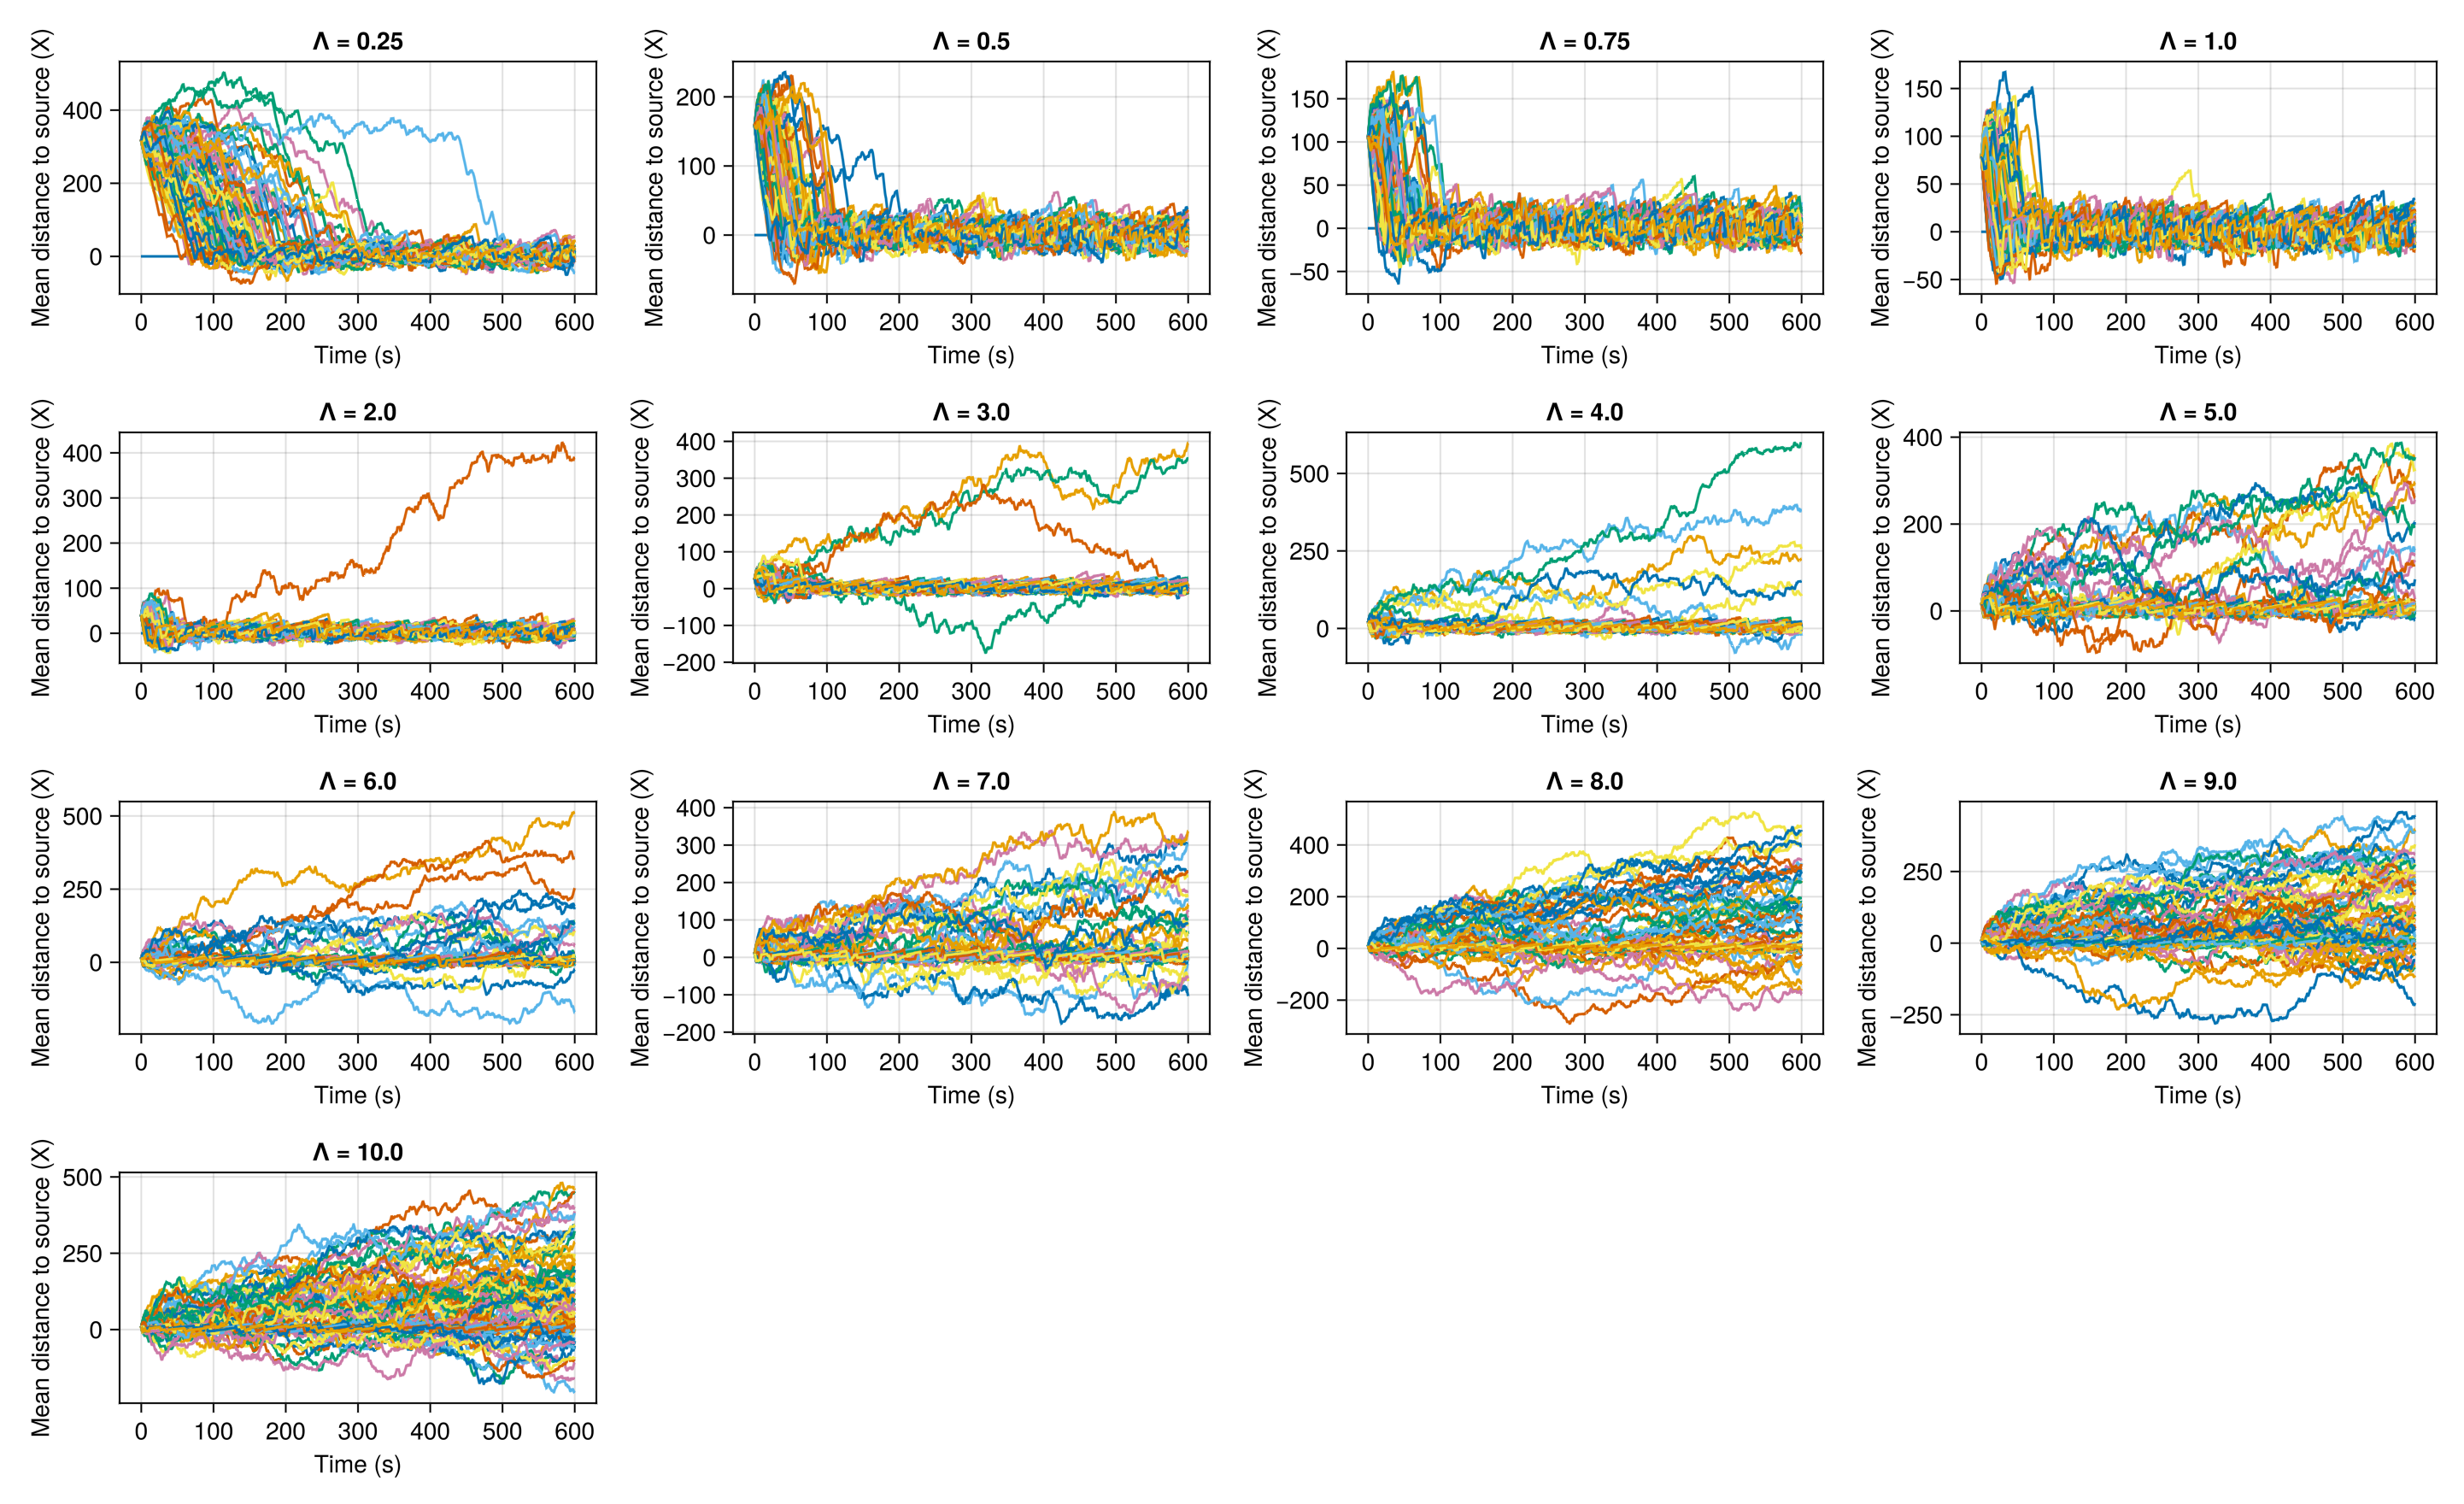

In [12]:
# Define the omega values to iterate over
lambdas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

n_files = length(lambdas)
steps = 60000

    rows = 4
    cols = 4
    fig3 = Figure(size=(900 * cols, 600 * rows))

    for (idx, lambda) in enumerate(lambdas)
    
        filename = @sprintf("fsb_10.0_lambda_%s.jld2", lambda)
        
        row = ceil(Int, idx / cols)
        col = (idx - 1) % cols + 1
        
        ax = Axis(fig3[row, col], 
                xlabel="Time (s)", 
                ylabel="Mean distance to source (X)",
                title="Λ = $lambda")

        jldopen(filename, "r") do file 
            for agent in 1:100
                mean_dist_x = Float64[] 
                for step in 1:10:steps
        
                    g = file[@sprintf("step_%06d", step)]

                    xs = 0
                    ys = 0

                    other_x = g["x"][agent]

                    dists_x = other_x .- xs

                    push!(mean_dist_x, mean(dists_x))
    
  
                end

                # Plotting X data
                lines!(ax, (1:10:steps)*0.01, mean_dist_x, label="Mean X")
                # lines!(ax, (1:10:steps)*0.01, mean_dist_x,  label="Mean X")
            end
        end
    end
fig3


In [14]:
save("Plots/Fixed_source_model/Trajectories/v10.png", fig3)

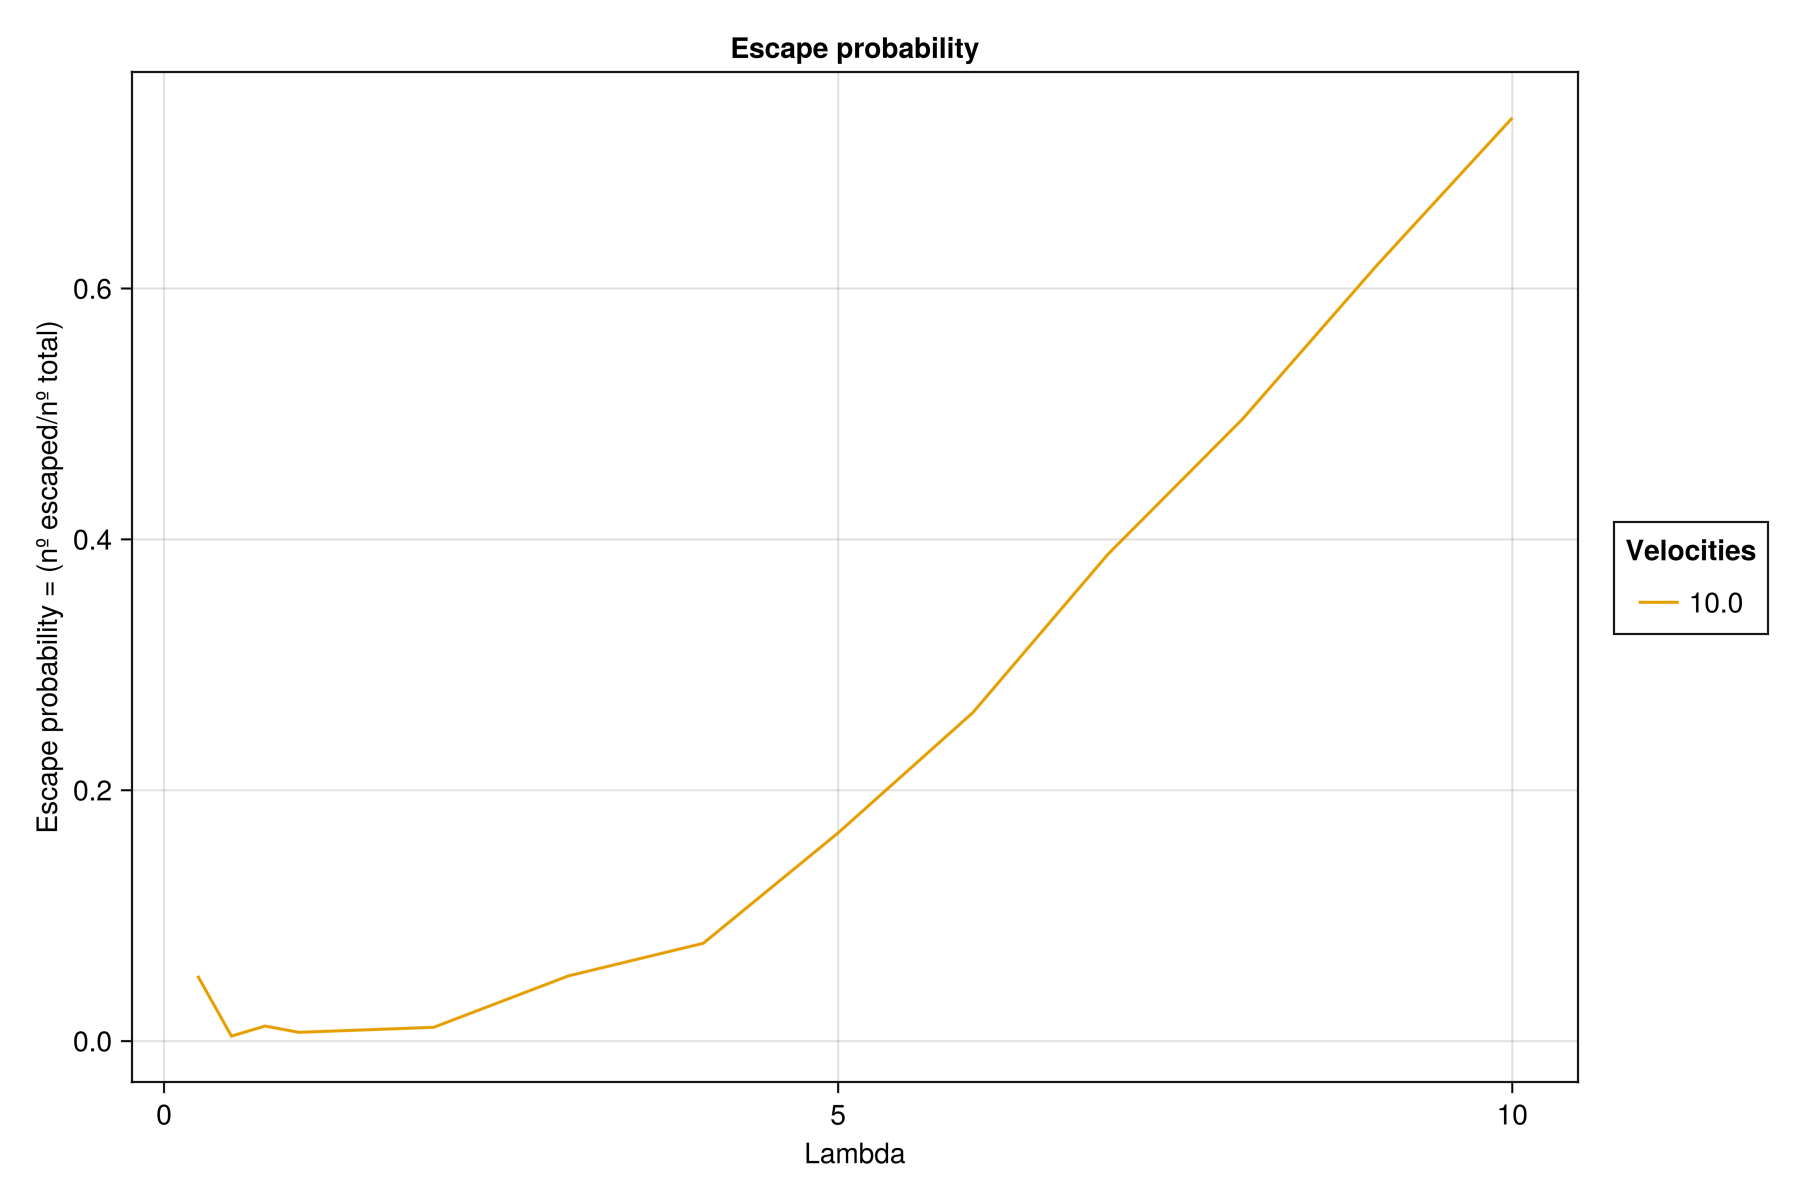

In [13]:
fig4 = Figure(size=(900,600))
ax = Axis(fig4[1,1], xlabel = "Lambda", ylabel = "Escape probability = (nº escaped/nº total)", title = "Escape probability")

colors = [
    # RGBf(0.0, 0.45, 0.70),   # blue
    RGBf(0.90, 0.62, 0.0),   # orange
    # RGBf(0.0, 0.62, 0.45),   # green
    # RGBf(0.80, 0.47, 0.65)   # magenta
]
escape_10 = Float64[]
velocities = [10.0]
for (idx,v) in enumerate(velocities)
    color = colors[idx]
    mask = (df_valid_agents.v .== v)
    agents = df_valid_agents.valid[mask]
    lambdas = df_valid_agents.lambda[mask]
    P = 1 .- (agents/1000) 
    escape_10 = P
    lines!(ax, lambdas, P, label = "$v", color = color)
end

fig4[1,2] = Legend(fig4, ax, "Velocities")
fig4

In [11]:
save("Plots/Fixed_source_model/escape_probability_v10_nova.png", fig4)

In [15]:
@save "escape_v10.jld2" escape_10

In [133]:
metrics_combined.sigma = (metrics_combined.sigma_x .+ metrics_combined.sigma_y) ./ 2

52-element Vector{Float64}:
   7.997005029012858
  14.18957215518925
  28.104851618262682
 139.0040563050444
   6.527805249649452
  11.694927044602215
  22.652339636978045
 113.55945529579321
   6.086481674350287
  10.637017218341033
   ⋮
  54.08484624766132
  16.715685313267997
   6.9395675382520565
  16.55612789714786
  52.350282383783956
  14.918534151554397
   6.866955692064997
  28.03156905242367
  51.07044121423655

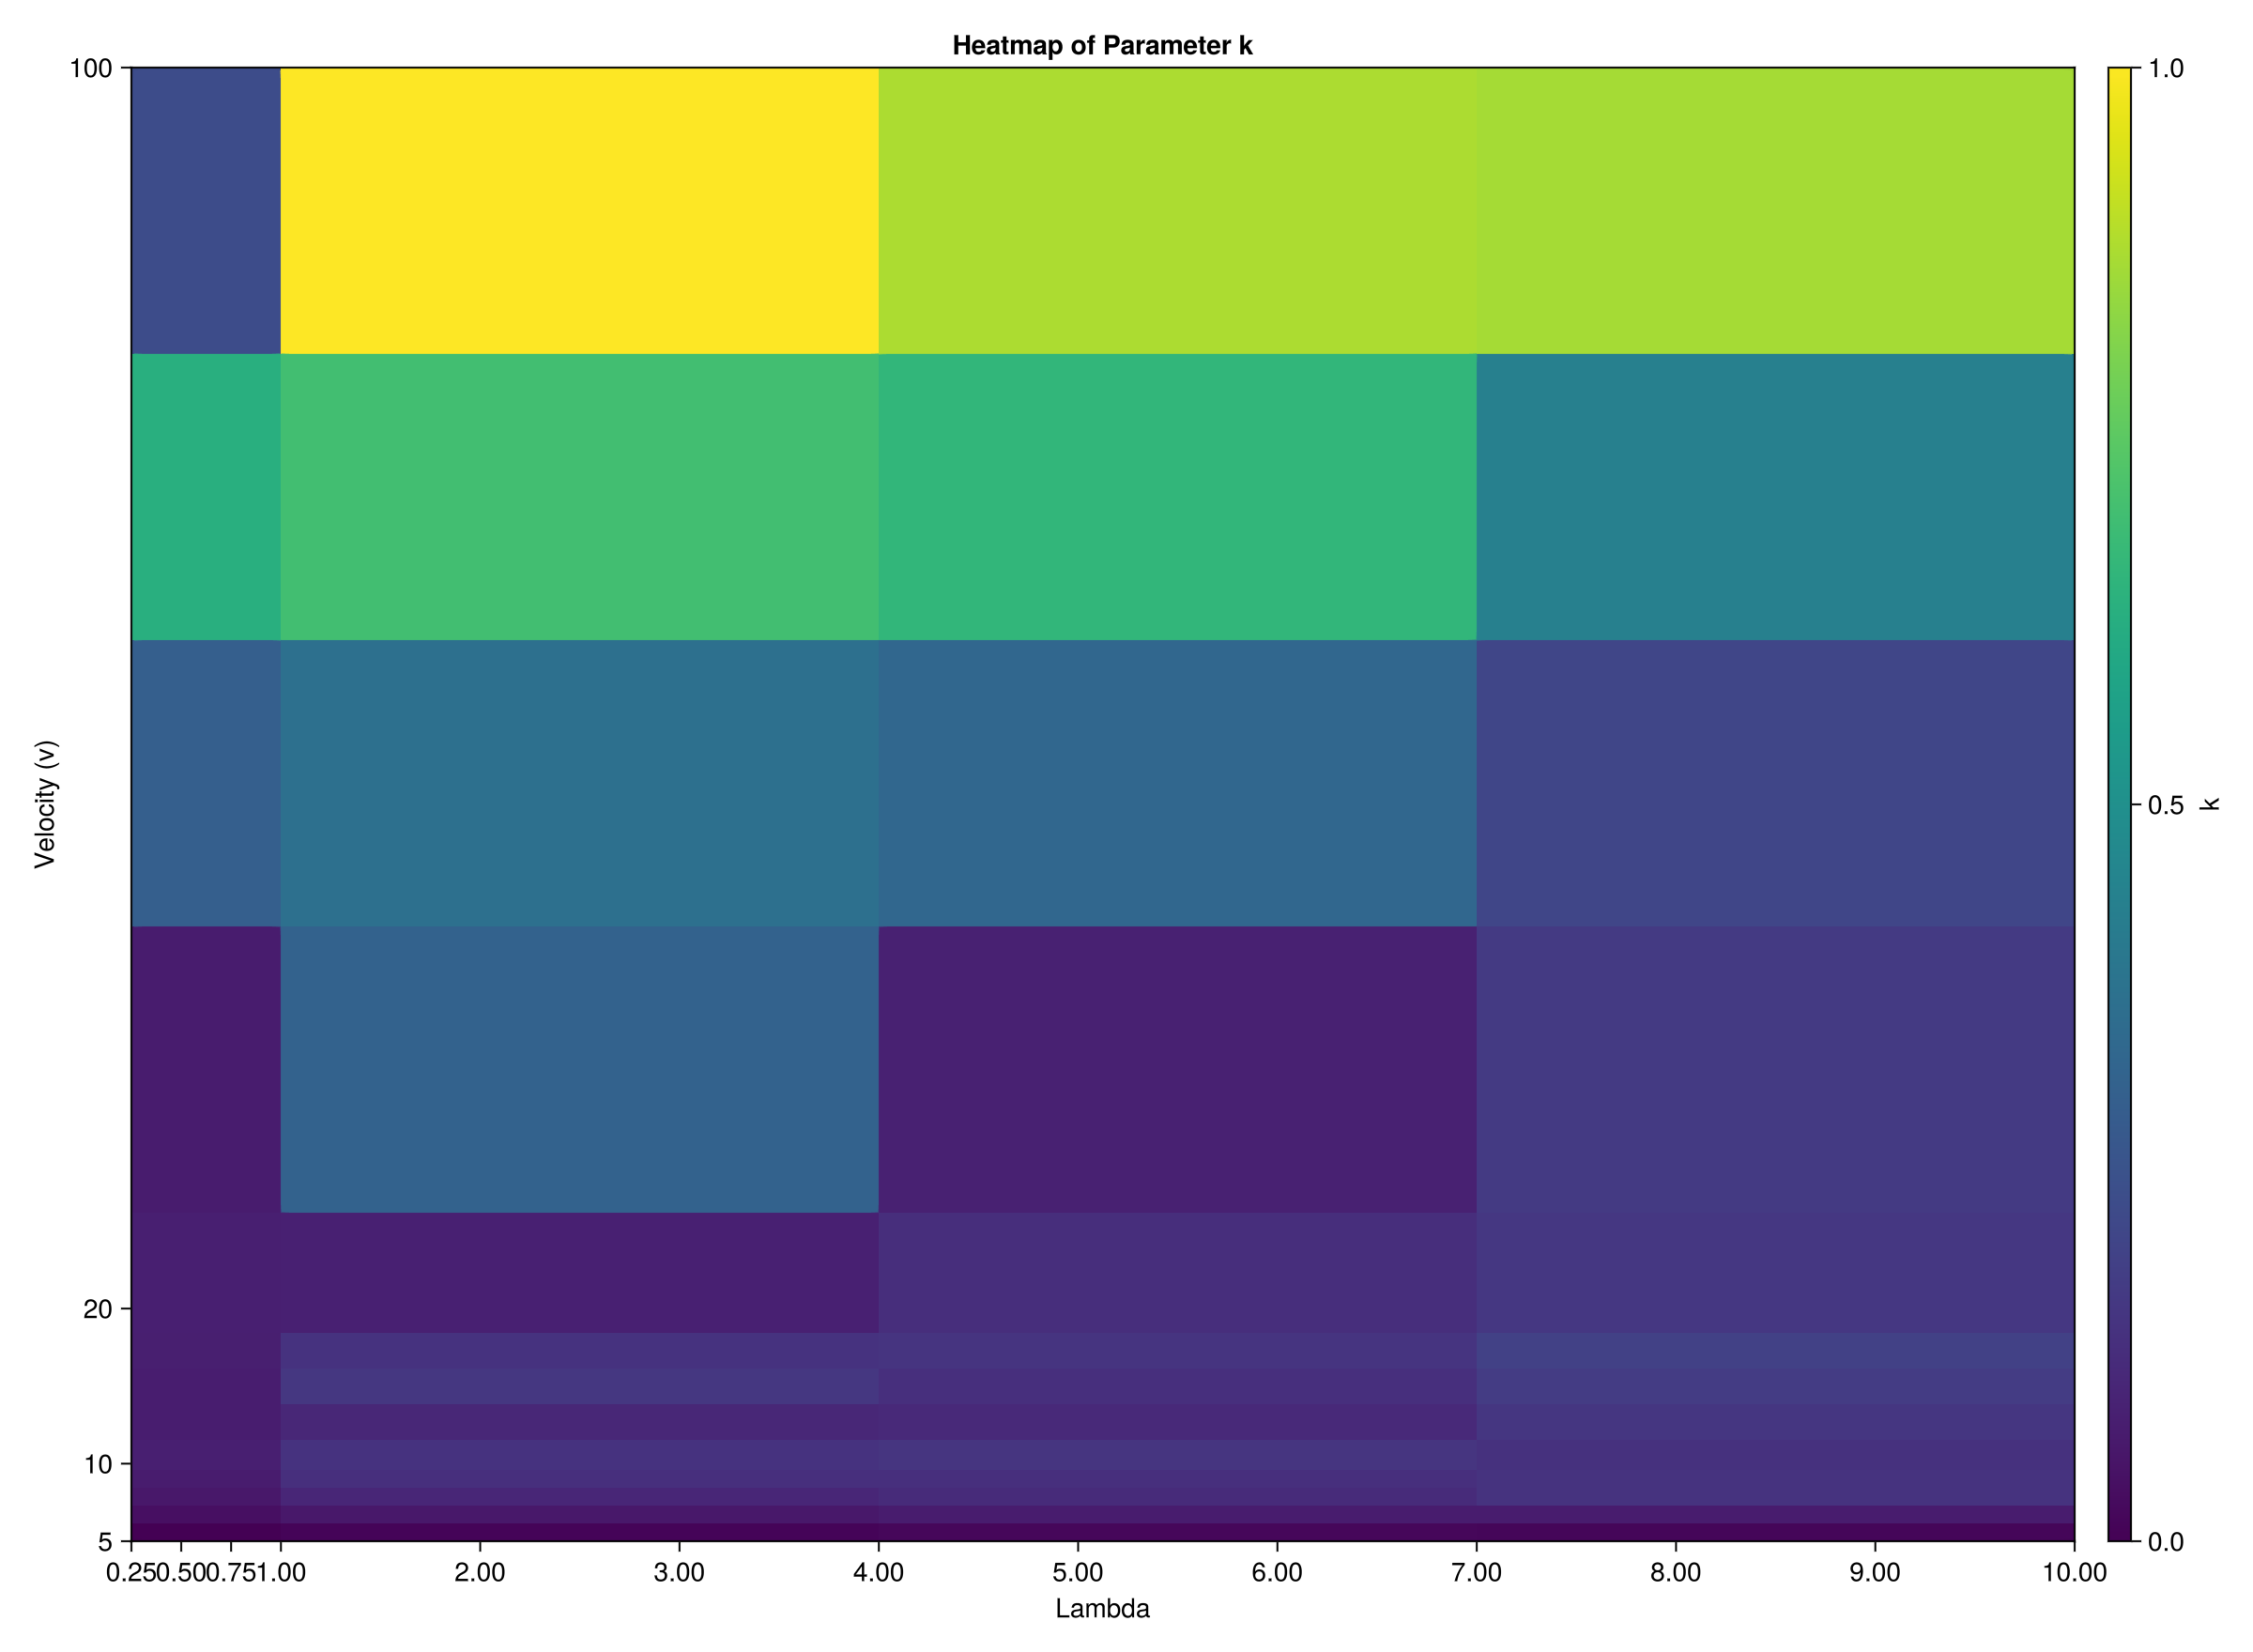

In [128]:
# --------------------------------------------------------

# Sort the dataframe
sort!(metrics_combined, [:lambda, :v])

# Define the specific order for the y-axis


# Get unique sorted values for x-axis (lambda)
unique_x = sort(unique(metrics_combined.lambda))
unique_y = sort(unique(metrics_combined.v))

# ---------------------------------------------------------
# 3. RESHAPE TO MATRIX (Using Indices)
# ---------------------------------------------------------
n_rows = length(unique_y)
n_cols = length(unique_x)
Z = Matrix{Float64}(undef, n_rows, n_cols)

# Fill the matrix
for (i, v_val) in enumerate(unique_y)
    for (j, x_val) in enumerate(unique_x)
        mask = (metrics_combined.lambda .== x_val) .& (metrics_combined.v .== v_val)
        if any(mask)
            Z[i, j] = mean(metrics_combined.k[mask])
        else
            Z[i, j] = NaN
        end
    end
end

# ---------------------------------------------------------
# 4. PLOT (Using Integer Indices for Y)
# ---------------------------------------------------------
fig = Figure(size=(1200, 900))
ax = Axis(fig[1, 1], 
          xlabel="Lambda", 
          ylabel="Velocity (v)",
          title="Heatmap of Parameter k",
          yticks = [5, 10, 20, 100], 
          xticks = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])

# Plot using integers. GLMakie will treat them as discrete positions.
hm = heatmap!(ax, unique_x, unique_y, Z, 
             colormap=:viridis)

# ---------------------------------------------------------
# 5. CUSTOMIZE Y-AXIS LABELS
# ---------------------------------------------------------
Colorbar(fig[1, 2], label="k")

fig

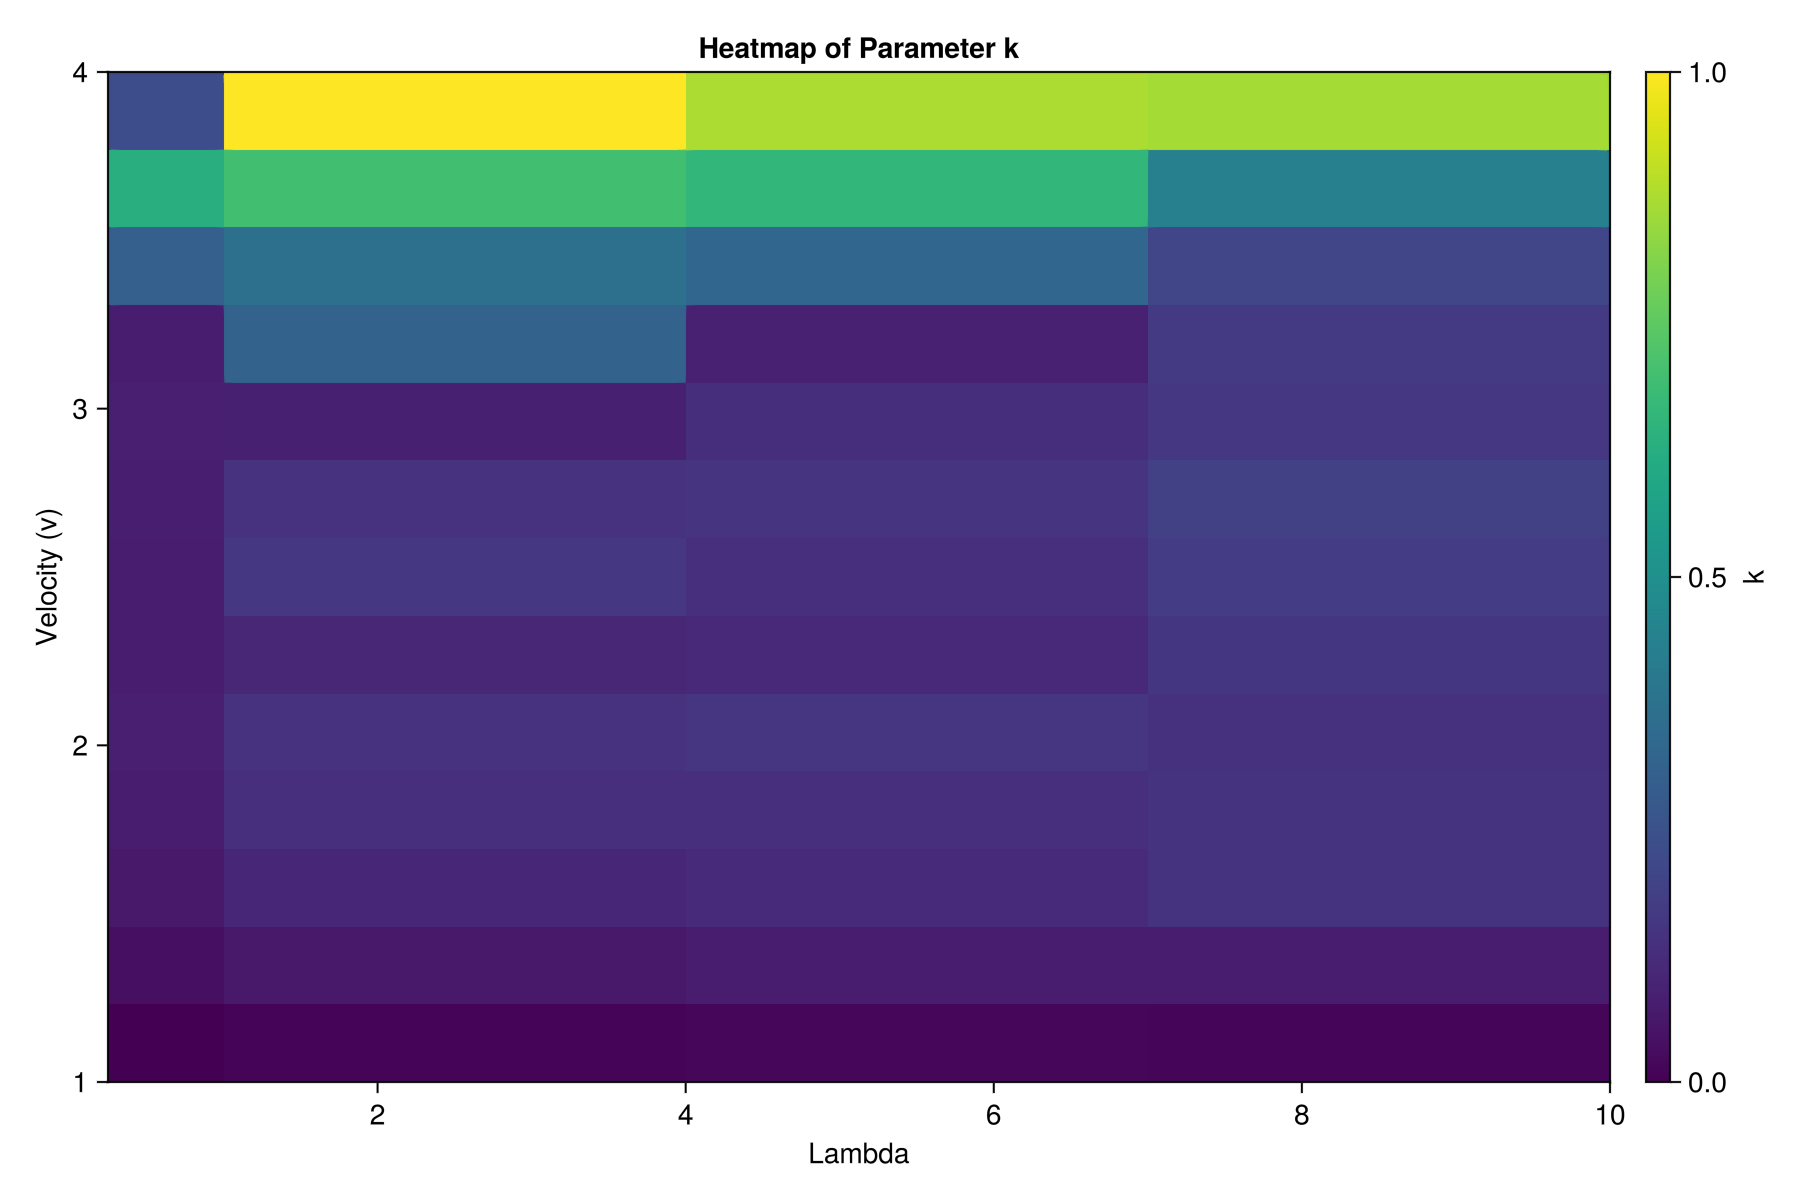

In [154]:
# ... [Your sorting and matrix creation code remains the same] ...

# ---------------------------------------------------------
# 4. PLOT (Using Integer Indices + Custom Labels)
# ---------------------------------------------------------
fig = Figure(size=(900, 600))
ax = Axis(fig[1, 1], 
          xlabel="Lambda", 
          ylabel="Velocity (v)",
          title="Heatmap of Parameter k")

# Create a vector of integer indices [1, 2, 3, 4] for the plot
# This ensures equal spacing regardless of the value magnitude
y_indices = 1:length(unique_y)

# Plot using integer indices
# Makie will treat these as discrete positions 1, 2, 3, 4
hm = heatmap!(ax, unique_x, y_indices, Z, 
              colormap=:viridis)

# ---------------------------------------------------------
# 5. CUSTOMIZE Y-AXIS LABELS
# ---------------------------------------------------------
# Replace the default 1, 2, 3, 4 labels with your actual velocity values
# yticks!(ax, y_indices, unique_y)

# # Optional: Adjust limits to ensure the ticks are centered
# ylims!(ax, 0.5, length(unique_y) + 0.5)

Colorbar(fig[1, 2], label="k")

fig

In [155]:
save("Plots/Fixed_source_model/heatmap_k.png", fig)

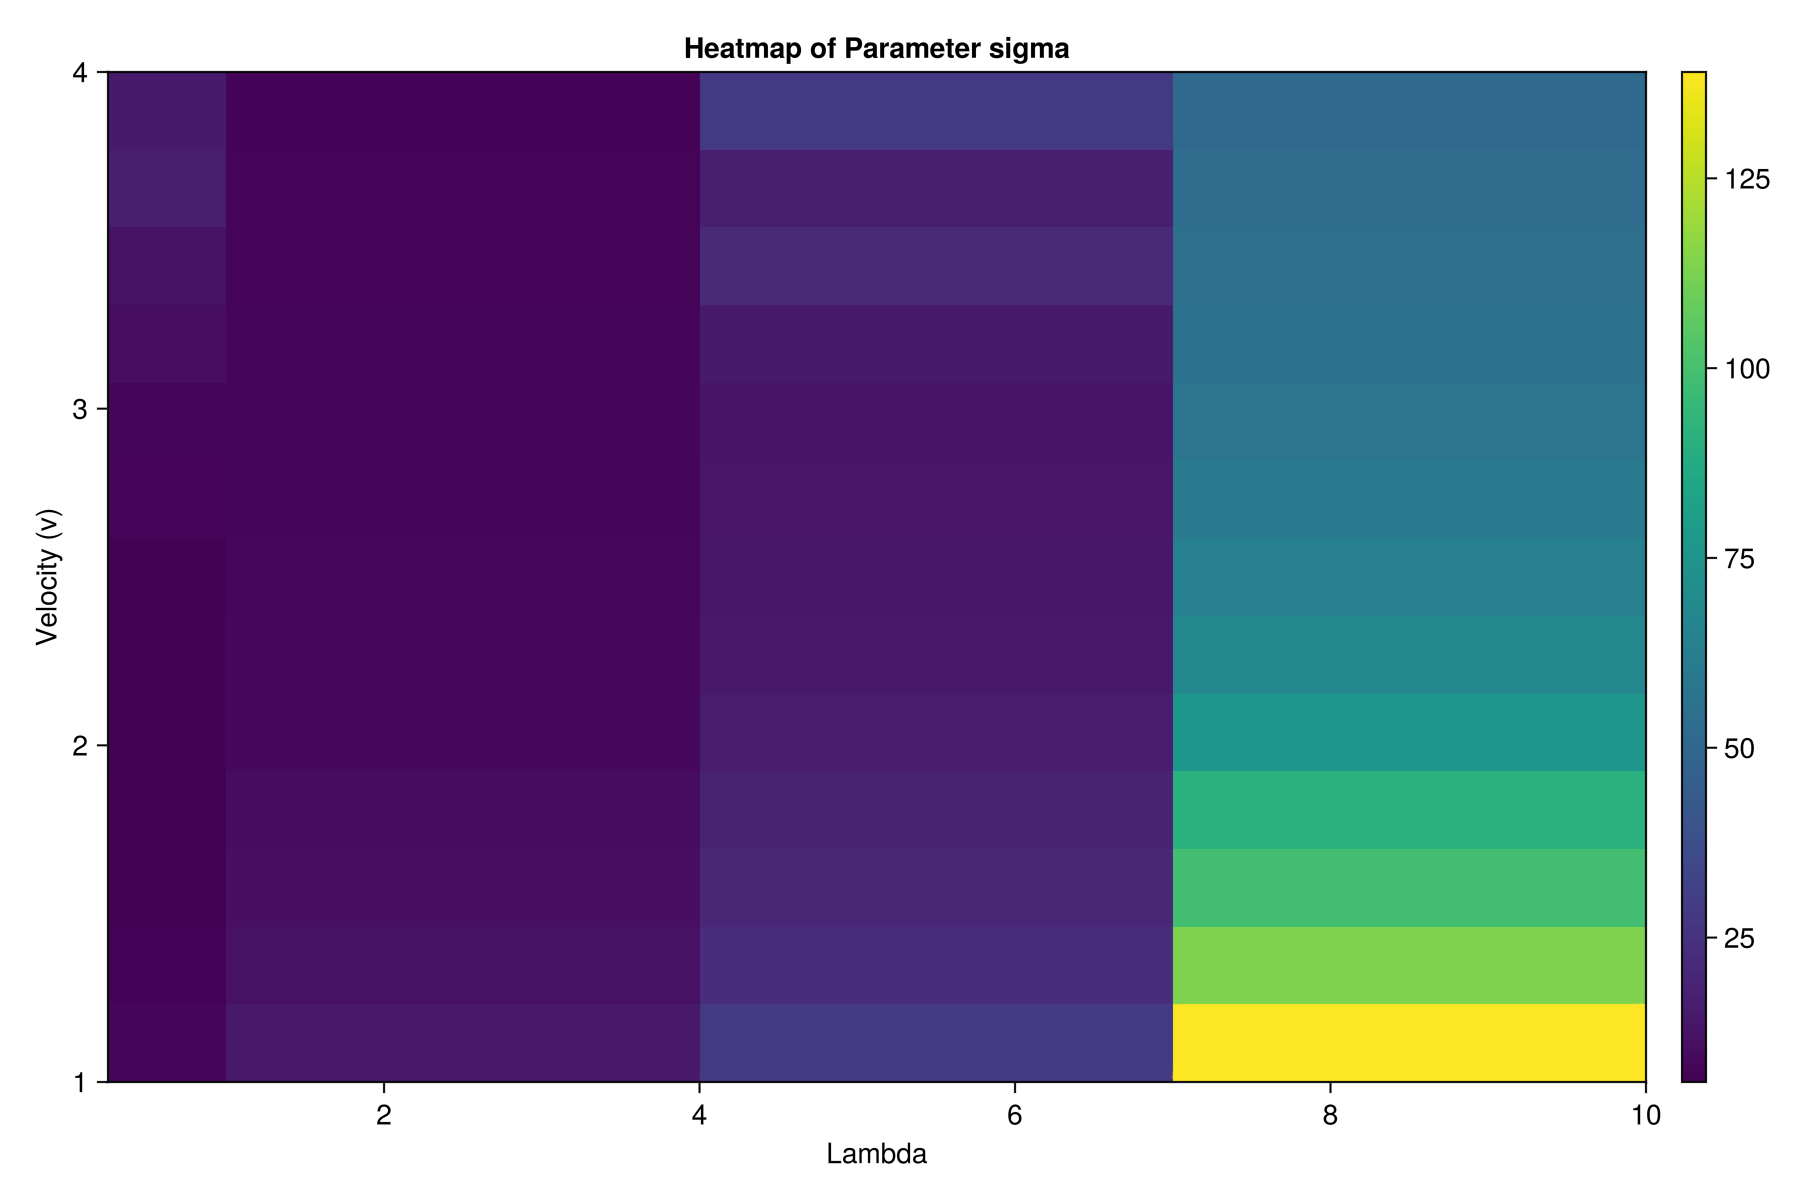

In [151]:
# --------------------------------------------------------

# Sort the dataframe
sort!(metrics_combined, [:lambda, :v])

# Define the specific order for the y-axis


# Get unique sorted values for x-axis (lambda)
unique_x = sort(unique(metrics_combined.lambda))
unique_y = sort(unique(metrics_combined.v))

# ---------------------------------------------------------
# 3. RESHAPE TO MATRIX (Using Indices)
# ---------------------------------------------------------
n_rows = length(unique_y)
n_cols = length(unique_x)
Z_2 = Matrix{Float64}(undef, n_rows, n_cols)

# Fill the matrix
for (i, v_val) in enumerate(unique_y)
    for (j, x_val) in enumerate(unique_x)
        mask = (metrics_combined.lambda .== x_val) .& (metrics_combined.v .== v_val)
        if any(mask)
            Z_2[i, j] = mean(metrics_combined.sigma[mask])
        else
            Z_2[i, j] = NaN
        end
    end
end

# ---------------------------------------------------------
# 4. PLOT (Using Integer Indices for Y)
# ---------------------------------------------------------
fig = Figure(size=(900, 600))
ax = Axis(fig[1, 1], 
          xlabel="Lambda", 
          ylabel="Velocity (v)",
          title="Heatmap of Parameter sigma")

# Create a vector of integer indices [1, 2, 3, 4] for the plot
# This ensures equal spacing regardless of the value magnitude
y_indices = 1:length(unique_y)

# Plot using integer indices
# Makie will treat these as discrete positions 1, 2, 3, 4
hm = heatmap!(ax, unique_x, y_indices, Z_2, 
              colormap=:viridis)

Colorbar(fig[1,2], hm)

fig

In [153]:
save("Plots/Fixed_source_model/heatmap_sigma.png", fig)